In [5]:
# ============================================================================
# CELL 1 — SETUP & CONFIGURATION
# ----------------------------------------------------------------------------
# Does 4 things:
#   1. Confirms which GPU Colab gave us (we want A100 for the real run)
#   2. Installs metric libraries (FID, LPIPS, precision/recall, KID)
#   3. Mounts Google Drive (Colab wipes local storage on disconnect — we
#      save ALL checkpoints/logs/outputs to Drive so nothing is ever lost)
#   4. Defines every hyperparameter in ONE config dict (no hardcoding)
# ============================================================================

# ---- 1. Which GPU did we get? ----
# For the real training run we want A100. For the cheap smoke test, T4 is fine.
!nvidia-smi --query-gpu=name,memory.total --format=csv

# ---- 2. Install metric libraries (torch/torchvision already in Colab) ----
!pip install -q pytorch-fid lpips prdc torch-fidelity

# ---- 3. Mount Google Drive (click the link, authorize once) ----
from google.colab import drive
drive.mount('/content/drive')

# ---- 4. Single source of truth: all hyperparameters live here ----
import os, torch

CONFIG = {
    # ----- paths -----
    "data_root":   "/content/data",                          # dataset (local = fast)
    "drive_root":  "/content/drive/MyDrive/cyclegan_task3",  # persistent storage

    # ----- image / data -----
    "image_size":  256,   # output resolution (Kaggle requires 256x256 RGB)
    "load_size":   286,   # resize to 286, then random-crop to 256 (augmentation)
    "channels":    3,     # RGB

    # ----- model (U-Net generator) -----
    "ngf":         64,    # base generator filters (doubles each downsample layer)
    "ndf":         64,    # base discriminator filters
    "unet_downs":  8,     # 256 -> 1 spatial (8 downsample steps); full U-Net depth

    # ----- training -----
    "batch_size":     1,       # CycleGAN standard; InstanceNorm prefers batch=1
    "epochs":         100,     # total epochs
    "decay_start":    50,      # constant LR until here, then linear decay to 0
    "steps_per_epoch":1000,    # subsample the ~7k photos to keep epochs fast
    "lr":             2e-4,    # CycleGAN paper learning rate
    "beta1":          0.5,     # Adam beta1 — MUST be 0.5 for GANs (not 0.9)
    "beta2":          0.999,
    "use_amp":        True,    # mixed precision — safe & fast on A100

    # ----- loss weights (the three forces on the generator) -----
    "lambda_cycle":    10.0,   # content preservation (round-trip). Dominant.
    "lambda_identity": 5.0,    # color/tone anchor (0.5 x cycle). Stops tinting.

    # ----- stability -----
    "pool_size":  50,          # replay buffer: show D a mix of old+new fakes

    # ----- logging / checkpointing -----
    "checkpoint_every": 10,    # save weights to Drive every N epochs (crash safety)
    "sample_every":     5,     # save a progress image grid every N epochs
    "seed":             42,
}

# ---- Reproducibility: fix all random seeds ----
import random, numpy as np
random.seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"]); torch.cuda.manual_seed_all(CONFIG["seed"])
torch.backends.cudnn.benchmark = True   # speeds up conv for fixed input sizes

# ---- Create Drive subfolders (safe if they already exist) ----
for sub in ["checkpoints", "samples", "logs", "outputs"]:
    os.makedirs(os.path.join(CONFIG["drive_root"], sub), exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("\n✅ Setup complete.")
print("   Device:", DEVICE)
print("   Generator: U-Net (depth", CONFIG["unet_downs"], ") | AMP:", CONFIG["use_amp"])
print("   Drive root:", CONFIG["drive_root"])


name, memory.total [MiB]
Tesla T4, 15360 MiB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Setup complete.
   Device: cuda
   Generator: U-Net (depth 8 ) | AMP: True
   Drive root: /content/drive/MyDrive/cyclegan_task3


In [7]:
# ============================================================================
# CELL 2 — DATA: copy Drive -> fast local disk, inspect .npz stats, sanity check
# ----------------------------------------------------------------------------
# Training reads thousands of images repeatedly; reading from Drive is slow.
# We copy once to Colab's local SSD (/content) for speed (~1-2 min).
# We ALSO inspect the two .npz files — likely pre-computed FID statistics,
# which let us compute local FID that matches the leaderboard.
# ============================================================================

import os, shutil, glob
import numpy as np

# ---- Paths: source (Drive) and destination (fast local) ----
DRIVE_DATA = os.path.join(CONFIG["drive_root"], "data")      # .../cyclegan_task3/data
MONET_DIR  = os.path.join(CONFIG["data_root"], "monet_jpg")  # /content/data/monet_jpg
PHOTO_DIR  = os.path.join(CONFIG["data_root"], "photo_jpg")  # /content/data/photo_jpg
os.makedirs(CONFIG["data_root"], exist_ok=True)

# ---- Copy image folders Drive -> local (skip if already copied) ----
def copy_if_needed(src, dst):
    if not os.path.exists(dst) or len(os.listdir(dst)) == 0:
        print(f"Copying {src} -> {dst} ...")
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        print(f"Already present: {dst}")

copy_if_needed(os.path.join(DRIVE_DATA, "monet_jpg"), MONET_DIR)
copy_if_needed(os.path.join(DRIVE_DATA, "photo_jpg"), PHOTO_DIR)

# ---- Count images ----
exts = ("*.jpg", "*.jpeg", "*.png")
monet_files = [f for e in exts for f in glob.glob(os.path.join(MONET_DIR, e))]
photo_files = [f for e in exts for f in glob.glob(os.path.join(PHOTO_DIR, e))]
print(f"\n✅ Monet images: {len(monet_files)}")
print(f"✅ Photo images: {len(photo_files)}")
assert len(monet_files) > 0 and len(photo_files) > 0, "❌ No images found!"

# ---- Inspect the two .npz stat files to learn what they contain ----
print("\n--- Inspecting .npz stats files ---")
for name in ["photo_stats.npz", "real_stats.npz"]:
    p = os.path.join(DRIVE_DATA, name)
    if os.path.exists(p):
        d = np.load(p)
        print(f"\n{name}:")
        for k in d.files:
            arr = d[k]
            print(f"   key='{k}'  shape={arr.shape}  dtype={arr.dtype}")
    else:
        print(f"\n{name}: NOT FOUND")


Copying /content/drive/MyDrive/cyclegan_task3/data/monet_jpg -> /content/data/monet_jpg ...
Copying /content/drive/MyDrive/cyclegan_task3/data/photo_jpg -> /content/data/photo_jpg ...


KeyboardInterrupt: 

In [6]:
# ============================================================================
# CELL 3 — UNPAIRED DATASET + AUGMENTATION + VISUALIZE
# ----------------------------------------------------------------------------
# Unpaired: each item returns one RANDOM Monet + one RANDOM Photo (independent).
# Normalized to [-1,1] to match the generator's Tanh output (the critical fix).
# We visualize + print value ranges to confirm correctness before training.
# ============================================================================

import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt

# ---- Augmentation: resize 286 -> random crop 256 -> flip -> [-1,1] ----
train_tf = T.Compose([
    T.Resize(CONFIG["load_size"]),            # -> 286
    T.RandomCrop(CONFIG["image_size"]),       # -> 256 (random position = augmentation)
    T.RandomHorizontalFlip(),                 # mirror augmentation
    T.ToTensor(),                             # -> [0,1]
    T.Normalize([0.5]*3, [0.5]*3),            # -> [-1,1]  (matches Tanh)
])

class UnpairedDataset(Dataset):
    """One random Monet + one random Photo per item (unpaired translation)."""
    def __init__(self, monet_files, photo_files, transform):
        self.monet, self.photo, self.tf = monet_files, photo_files, transform
    def __len__(self):
        return max(len(self.monet), len(self.photo))   # see all photos each epoch
    def __getitem__(self, idx):
        m = Image.open(random.choice(self.monet)).convert("RGB")
        p = Image.open(random.choice(self.photo)).convert("RGB")
        return self.tf(m), self.tf(p)

dataset = UnpairedDataset(monet_files, photo_files, train_tf)
loader  = DataLoader(dataset, batch_size=CONFIG["batch_size"],
                     shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

# ---- Visualize + verify [-1,1] range ----
def denorm(x): return (x * 0.5 + 0.5).clamp(0, 1)   # for display only

mb, pb = next(iter(loader))
print("Monet range:", round(mb.min().item(),2), "to", round(mb.max().item(),2))
print("Photo range:", round(pb.min().item(),2), "to", round(pb.max().item(),2))

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(denorm(mb[0]).permute(1,2,0)); ax[0].set_title("Monet (A)"); ax[0].axis("off")
ax[1].imshow(denorm(pb[0]).permute(1,2,0)); ax[1].set_title("Photo (B)"); ax[1].axis("off")
plt.tight_layout(); plt.show()
print("✅ Images should look correct; ranges should be ~ -1 to 1.")


NameError: name 'monet_files' is not defined

In [4]:
# ============================================================================
# CELL 4 — U-NET GENERATOR
# ----------------------------------------------------------------------------
# WHY U-NET (vs teammate's ResNet):
#   A U-Net is an encoder-decoder with SKIP CONNECTIONS. The encoder shrinks
#   the image down to a tiny bottleneck (capturing "what is in the scene"),
#   the decoder builds it back up. Skip connections copy encoder features
#   straight across to the decoder at matching resolutions.
#
#   For Monet<->Photo this is ideal: the skips preserve SPATIAL STRUCTURE
#   (where the trees/horizon/buildings are) while the bottleneck transforms
#   STYLE (color, texture, brushstrokes). ResNet preserves content via
#   residual learning; U-Net preserves it via skips — a genuinely different
#   mechanism, which is why it's a valid distinct architecture.
#
# DESIGN:
#   - 8 downsampling steps: 256 -> 128 -> 64 -> 32 -> 16 -> 8 -> 4 -> 2 -> 1
#   - 8 upsampling steps mirror it back to 256
#   - InstanceNorm (per-image normalization — right for style transfer)
#   - LeakyReLU in encoder, ReLU in decoder (standard U-Net GAN convention)
#   - Dropout in the first few decoder layers (regularization -> helps MiFID)
#   - Final Tanh -> output in [-1,1] (matches our normalized inputs)
# ============================================================================

import torch
import torch.nn as nn

class UNetDown(nn.Module):
    """One encoder step: Conv (stride 2, halves size) -> InstanceNorm -> LeakyReLU."""
    def __init__(self, in_c, out_c, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1, bias=False)]
        if normalize:                              # first layer skips norm (standard)
            layers.append(nn.InstanceNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))           # LeakyReLU: keeps small negative signal
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    """One decoder step: TransposeConv (doubles size) -> InstanceNorm -> ReLU (+optional Dropout).
       Then CONCATENATE the matching encoder feature map (the skip connection)."""
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(out_c),
            nn.ReLU(inplace=True),
        ]
        if dropout:                                # dropout regularizes -> less memorization
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip):
        x = self.model(x)
        return torch.cat([x, skip], dim=1)         # <-- THE SKIP CONNECTION (channel concat)

class UNetGenerator(nn.Module):
    """Full U-Net generator: 256x256x3 -> 256x256x3, value range [-1,1]."""
    def __init__(self, in_c=3, out_c=3, ngf=64):
        super().__init__()
        # ----- ENCODER (downsampling path): 256 -> 1 -----
        self.d1 = UNetDown(in_c,    ngf,    normalize=False)  # 256 -> 128  (64)
        self.d2 = UNetDown(ngf,     ngf*2)                    # 128 -> 64   (128)
        self.d3 = UNetDown(ngf*2,   ngf*4)                    # 64  -> 32   (256)
        self.d4 = UNetDown(ngf*4,   ngf*8)                    # 32  -> 16   (512)
        self.d5 = UNetDown(ngf*8,   ngf*8)                    # 16  -> 8    (512)
        self.d6 = UNetDown(ngf*8,   ngf*8)                    # 8   -> 4    (512)
        self.d7 = UNetDown(ngf*8,   ngf*8)                    # 4   -> 2    (512)
        self.d8 = UNetDown(ngf*8,   ngf*8, normalize=False)   # 2   -> 1    (512) bottleneck

        # ----- DECODER (upsampling path): 1 -> 256 -----
        # in_c doubles (except first up) because of concatenated skip features.
        self.u1 = UNetUp(ngf*8,   ngf*8, dropout=0.5)         # 1  -> 2
        self.u2 = UNetUp(ngf*16,  ngf*8, dropout=0.5)         # 2  -> 4
        self.u3 = UNetUp(ngf*16,  ngf*8, dropout=0.5)         # 4  -> 8
        self.u4 = UNetUp(ngf*16,  ngf*8)                      # 8  -> 16
        self.u5 = UNetUp(ngf*16,  ngf*4)                      # 16 -> 32
        self.u6 = UNetUp(ngf*8,   ngf*2)                      # 32 -> 64
        self.u7 = UNetUp(ngf*4,   ngf)                        # 64 -> 128
        # final upsample back to full res + Tanh
        self.final = nn.Sequential(
            nn.ConvTranspose2d(ngf*2, out_c, kernel_size=4, stride=2, padding=1),
            nn.Tanh()                                         # -> [-1,1]
        )

    def forward(self, x):
        # encode (store each for the skip connections)
        d1 = self.d1(x); d2 = self.d2(d1); d3 = self.d3(d2); d4 = self.d4(d3)
        d5 = self.d5(d4); d6 = self.d6(d5); d7 = self.d7(d6); d8 = self.d8(d7)
        # decode, concatenating the MIRRORED encoder feature each step
        u1 = self.u1(d8, d7)
        u2 = self.u2(u1, d6)
        u3 = self.u3(u2, d5)
        u4 = self.u4(u3, d4)
        u5 = self.u5(u4, d3)
        u6 = self.u6(u5, d2)
        u7 = self.u7(u6, d1)
        return self.final(u7)

# ---- Quick sanity test: shape in == shape out, and param count ----
g_test = UNetGenerator(ngf=CONFIG["ngf"])
dummy = torch.randn(1, 3, CONFIG["image_size"], CONFIG["image_size"])
out = g_test(dummy)
n_params = sum(p.numel() for p in g_test.parameters())
print("Input shape :", tuple(dummy.shape))
print("Output shape:", tuple(out.shape), "  (should match input)")
print("Output range:", round(out.min().item(),2), "to", round(out.max().item(),2), " (should be ~ -1 to 1)")
print(f"Generator parameters: {n_params/1e6:.2f}M")
del g_test, dummy, out   # free memory


Input shape : (1, 3, 256, 256)
Output shape: (1, 3, 256, 256)   (should match input)
Output range: -1.0 to 1.0  (should be ~ -1 to 1)
Generator parameters: 54.40M


In [5]:
# ============================================================================
# CELL 5 — PATCHGAN DISCRIMINATOR (70x70 receptive field)
# ----------------------------------------------------------------------------
# WHY PATCHGAN (not a single real/fake score for the whole image):
#   Style is LOCAL — brushstrokes, color patches, textures. A PatchGAN outputs
#   a GRID of real/fake scores, where each cell judges one ~70x70 patch of the
#   input. This forces the generator to get LOCAL texture right everywhere,
#   not just fool a global "is this real?" check. It also has far fewer
#   parameters than a full-image classifier.
#
#   Output is a (1 x 30 x 30) map (not a scalar). During training we compare
#   this whole map to a grid of 1s (real) or 0s (fake) using MSE (LSGAN).
#
# DESIGN (standard CycleGAN 70x70 PatchGAN):
#   C64 -> C128 -> C256 -> C512 -> final 1-channel conv
#   - Conv stride 2 downsamples; InstanceNorm (except first layer); LeakyReLU
#   - No sigmoid at the end — LSGAN uses raw outputs with MSE loss
# ============================================================================

import torch
import torch.nn as nn

class PatchDiscriminator(nn.Module):
    def __init__(self, in_c=3, ndf=64):
        super().__init__()

        def block(in_f, out_f, normalize=True, stride=2):
            # one conv block: Conv (stride) -> [InstanceNorm] -> LeakyReLU
            layers = [nn.Conv2d(in_f, out_f, kernel_size=4, stride=stride, padding=1,
                                bias=not normalize)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_c,  ndf,   normalize=False),  # 256 -> 128  (first layer: no norm)
            *block(ndf,   ndf*2),                   # 128 -> 64
            *block(ndf*2, ndf*4),                   # 64  -> 32
            *block(ndf*4, ndf*8, stride=1),         # stays 31x31 (stride 1 keeps resolution)
            # final conv -> 1 channel score map (NO sigmoid; LSGAN uses raw values)
            nn.Conv2d(ndf*8, 1, kernel_size=4, stride=1, padding=1)  # -> (1, 30, 30)
        )

    def forward(self, x):
        return self.model(x)   # returns a (B,1,30,30) patch score map

# ---- Sanity test: feed a fake image, check the output grid + param count ----
d_test = PatchDiscriminator(ndf=CONFIG["ndf"])
dummy  = torch.randn(1, 3, CONFIG["image_size"], CONFIG["image_size"])
out    = d_test(dummy)
n_params = sum(p.numel() for p in d_test.parameters())
print("Input shape :", tuple(dummy.shape))
print("Output shape:", tuple(out.shape), "  (patch grid, e.g. (1,1,30,30))")
print(f"Discriminator parameters: {n_params/1e6:.2f}M")
del d_test, dummy, out


Input shape : (1, 3, 256, 256)
Output shape: (1, 1, 30, 30)   (patch grid, e.g. (1,1,30,30))
Discriminator parameters: 2.76M


In [6]:
# ============================================================================
# CELL 6 — LOSSES, REPLAY BUFFER, WEIGHT INITIALIZATION
# ----------------------------------------------------------------------------
# Three ingredients that make GAN training actually stable:
#
#   1. WEIGHT INIT — Normal(0, 0.02). A deep U-Net with default init can have
#      vanishing/exploding gradients. The CycleGAN paper init fixes this.
#
#   2. LOSS FUNCTIONS — the "three forces" on the generator:
#        - Adversarial (LSGAN/MSE): "look like a real target-domain image"
#        - Cycle (L1, x10):         "round-trip must reconstruct the original"
#        - Identity (L1, x5):       "don't recolor an already-correct image"
#
#   3. REPLAY BUFFER — show the discriminator a MIX of current + past fakes.
#      Without it, D only ever sees the generator's newest trick and the two
#      oscillate. The buffer stabilizes D -> stabilizes the whole game.
# ============================================================================

import torch
import torch.nn as nn
import random

# ---------- 1. WEIGHT INITIALIZATION ----------
def init_weights(net):
    """Initialize conv / norm layers with Normal(0, 0.02) — CycleGAN standard."""
    def _init(m):
        classname = m.__class__.__name__
        if hasattr(m, "weight") and ("Conv" in classname or "Linear" in classname):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
            if getattr(m, "bias", None) is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif "InstanceNorm" in classname and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0.0)
    net.apply(_init)
    return net

# ---------- 2. LOSS FUNCTIONS ----------
# Adversarial loss = MSE (this is what makes it LSGAN, not vanilla GAN).
# LSGAN gives smooth gradients even when D is confident -> more stable than BCE.
adversarial_loss = nn.MSELoss()   # compares D's patch map to all-1s or all-0s
cycle_loss       = nn.L1Loss()    # pixel-wise reconstruction after round-trip
identity_loss    = nn.L1Loss()    # pixel-wise "leave correct images unchanged"

# ---------- 3. REPLAY BUFFER ----------
class ReplayBuffer:
    """Stores past generated images; when D trains, serves a 50/50 mix of
       the newest fake and a random old fake. Reduces oscillation."""
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []
    def push_and_pop(self, images):
        out = []
        for img in images:                      # process each image in the batch
            img = img.unsqueeze(0)              # keep batch dim -> (1,C,H,W)
            if len(self.data) < self.max_size:  # buffer not full -> store & use current
                self.data.append(img)
                out.append(img)
            else:
                if random.random() > 0.5:       # 50%: return an OLD fake, store the new one
                    i = random.randint(0, self.max_size - 1)
                    out.append(self.data[i].clone())
                    self.data[i] = img
                else:                           # 50%: just use the current fake
                    out.append(img)
        return torch.cat(out, dim=0)

# Two buffers — one per discriminator (fake Monets, fake Photos).
fake_M_buffer = ReplayBuffer(CONFIG["pool_size"])
fake_P_buffer = ReplayBuffer(CONFIG["pool_size"])

print("✅ Losses ready: LSGAN (MSE) + cycle (L1 x%.0f) + identity (L1 x%.0f)"
      % (CONFIG["lambda_cycle"], CONFIG["lambda_identity"]))
print("✅ Replay buffers ready (size %d each)" % CONFIG["pool_size"])
print("✅ Weight init function ready: Normal(0, 0.02)")


✅ Losses ready: LSGAN (MSE) + cycle (L1 x10) + identity (L1 x5)
✅ Replay buffers ready (size 50 each)
✅ Weight init function ready: Normal(0, 0.02)


In [7]:
# ============================================================================
# CELL 7 — INSTANTIATE EVERYTHING + RESUME-FROM-CHECKPOINT
# ----------------------------------------------------------------------------
# Builds the 4 networks, 2 optimizers, 2 LR schedulers, the AMP scaler, and a
# resume system. If Colab disconnects mid-training, re-running Cells 1-7 then
# Cell 8 will AUTOMATICALLY pick up from the last saved epoch on Drive.
#
# NAMING (competition convention: A=Monet, B=Photo):
#   G_M2P : Monet -> Photo   (the leaderboard star: makes pred_A2B)
#   G_P2M : Photo -> Monet   (needed for the cycle, makes pred_B2A)
#   D_P   : judges photos     (critic for G_M2P)
#   D_M   : judges Monets     (critic for G_P2M)
# ============================================================================

import torch, os, glob
import torch.optim as optim

# ---------- 1. Build the 4 networks, move to GPU, init weights ----------
G_M2P = init_weights(UNetGenerator(ngf=CONFIG["ngf"])).to(DEVICE)   # Monet -> Photo
G_P2M = init_weights(UNetGenerator(ngf=CONFIG["ngf"])).to(DEVICE)   # Photo -> Monet
D_P   = init_weights(PatchDiscriminator(ndf=CONFIG["ndf"])).to(DEVICE)  # judges Photos
D_M   = init_weights(PatchDiscriminator(ndf=CONFIG["ndf"])).to(DEVICE)  # judges Monets

# ---------- 2. Optimizers ----------
# Both generators share ONE optimizer (they're trained together each step).
# Each discriminator gets its own. beta1=0.5 is mandatory for GAN stability.
opt_G = optim.Adam(list(G_M2P.parameters()) + list(G_P2M.parameters()),
                   lr=CONFIG["lr"], betas=(CONFIG["beta1"], CONFIG["beta2"]))
opt_D_P = optim.Adam(D_P.parameters(), lr=CONFIG["lr"], betas=(CONFIG["beta1"], CONFIG["beta2"]))
opt_D_M = optim.Adam(D_M.parameters(), lr=CONFIG["lr"], betas=(CONFIG["beta1"], CONFIG["beta2"]))

# ---------- 3. LR schedulers (constant, then linear decay to 0) ----------
# Keep LR flat for `decay_start` epochs, then linearly ramp it down to 0 by
# the final epoch. This lets the model converge smoothly instead of jittering.
def lambda_rule(epoch):
    decay_len = CONFIG["epochs"] - CONFIG["decay_start"]
    if epoch < CONFIG["decay_start"]:
        return 1.0
    return max(0.0, 1.0 - (epoch - CONFIG["decay_start"]) / float(decay_len))

sched_G   = optim.lr_scheduler.LambdaLR(opt_G,   lr_lambda=lambda_rule)
sched_D_P = optim.lr_scheduler.LambdaLR(opt_D_P, lr_lambda=lambda_rule)
sched_D_M = optim.lr_scheduler.LambdaLR(opt_D_M, lr_lambda=lambda_rule)

# ---------- 4. Mixed-precision scaler (A100 speed boost) ----------
scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"])

# ---------- 5. RESUME LOGIC ----------
CKPT_DIR = os.path.join(CONFIG["drive_root"], "checkpoints")

def save_checkpoint(epoch, tag="latest"):
    """Save all weights + optimizer + scheduler state to Drive."""
    path = os.path.join(CKPT_DIR, f"ckpt_{tag}.pth")
    torch.save({
        "epoch":    epoch,
        "G_M2P":    G_M2P.state_dict(),
        "G_P2M":    G_P2M.state_dict(),
        "D_P":      D_P.state_dict(),
        "D_M":      D_M.state_dict(),
        "opt_G":    opt_G.state_dict(),
        "opt_D_P":  opt_D_P.state_dict(),
        "opt_D_M":  opt_D_M.state_dict(),
        "sched_G":  sched_G.state_dict(),
        "sched_D_P":sched_D_P.state_dict(),
        "sched_D_M":sched_D_M.state_dict(),
        "scaler":   scaler.state_dict(),
    }, path)

def load_checkpoint(tag="latest"):
    """Load state from Drive. Returns the epoch to resume FROM (next epoch)."""
    path = os.path.join(CKPT_DIR, f"ckpt_{tag}.pth")
    if not os.path.exists(path):
        print("No checkpoint found — starting fresh from epoch 0.")
        return 0
    ck = torch.load(path, map_location=DEVICE)
    G_M2P.load_state_dict(ck["G_M2P"]);  G_P2M.load_state_dict(ck["G_P2M"])
    D_P.load_state_dict(ck["D_P"]);      D_M.load_state_dict(ck["D_M"])
    opt_G.load_state_dict(ck["opt_G"])
    opt_D_P.load_state_dict(ck["opt_D_P"]); opt_D_M.load_state_dict(ck["opt_D_M"])
    sched_G.load_state_dict(ck["sched_G"])
    sched_D_P.load_state_dict(ck["sched_D_P"]); sched_D_M.load_state_dict(ck["sched_D_M"])
    scaler.load_state_dict(ck["scaler"])
    resume = ck["epoch"] + 1
    print(f"✅ Resumed from checkpoint — continuing at epoch {resume}")
    return resume

# Try to resume automatically (0 if no checkpoint exists yet).
START_EPOCH = load_checkpoint("latest")

# ---------- Summary ----------
total_params = sum(p.numel() for net in [G_M2P, G_P2M, D_P, D_M]
                   for p in net.parameters())
print(f"\n✅ Models on {DEVICE}. Total params (all 4 nets): {total_params/1e6:.2f}M")
print(f"   Generators: 2 x U-Net | Discriminators: 2 x PatchGAN")
print(f"   LR decay starts at epoch {CONFIG['decay_start']} / {CONFIG['epochs']}")
print(f"   Resume point: epoch {START_EPOCH}")


No checkpoint found — starting fresh from epoch 0.

✅ Models on cuda. Total params (all 4 nets): 114.34M
   Generators: 2 x U-Net | Discriminators: 2 x PatchGAN
   LR decay starts at epoch 50 / 100
   Resume point: epoch 0


/tmp/ipykernel_2326/1704208133.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"])


In [9]:
# ============================================================================
# CELL 8a — SHARED DEFINITIONS (needed by both smoke test and full training)
# ----------------------------------------------------------------------------
# These helpers are used by the smoke test (8b) AND the full training loop (8).
# Run this cell once, then the smoke test will work.
# ============================================================================

import torch, os, time, csv
import torchvision.utils as vutils

# ---- Real/fake target maps for the 30x30 PatchGAN output (LSGAN) ----
def real_target(x):  return torch.ones_like(x)    # "real" -> all 1s
def fake_target(x):  return torch.zeros_like(x)   # "fake" -> all 0s

# ---- Logging setup: raw log file + per-epoch CSV on Drive ----
LOG_PATH = os.path.join(CONFIG["drive_root"], "logs", "train.log")
CSV_PATH = os.path.join(CONFIG["drive_root"], "logs", "metrics_per_epoch.csv")
def log(msg):
    print(msg)
    with open(LOG_PATH, "a") as f:
        f.write(msg + "\n")

if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        csv.writer(f).writerow(
            ["epoch","G_loss","D_loss","cycle_loss","identity_loss",
             "adv_loss","grad_norm_G","nan_count","sec_per_epoch"])

# ---- Fixed samples: same images visualized across epochs to watch progress ----
fixed_monet, fixed_photo = next(iter(loader))
fixed_monet = fixed_monet.to(DEVICE); fixed_photo = fixed_photo.to(DEVICE)

def save_samples(epoch):
    """Grid: Monet->fakePhoto->recMonet  and  Photo->fakeMonet->recPhoto."""
    G_M2P.eval(); G_P2M.eval()
    with torch.no_grad():
        fake_photo = G_M2P(fixed_monet)
        rec_monet  = G_P2M(fake_photo)
        fake_monet = G_P2M(fixed_photo)
        rec_photo  = G_M2P(fake_monet)
    grid = torch.cat([fixed_monet, fake_photo, rec_monet,
                      fixed_photo, fake_monet, rec_photo], dim=0)
    grid = (grid * 0.5 + 0.5).clamp(0,1)
    path = os.path.join(CONFIG["drive_root"], "samples", f"epoch_{epoch:03d}.png")
    vutils.save_image(grid, path, nrow=3)
    G_M2P.train(); G_P2M.train()
    return path

print("✅ Definitions ready: real_target, fake_target, log(), save_samples()")


✅ Definitions ready: real_target, fake_target, log(), save_samples()


In [10]:
# ============================================================================
# CELL 8b — SMOKE TEST (run this BEFORE the real training)
# ----------------------------------------------------------------------------
# Temporarily shrinks steps to 20 and runs ONE epoch end-to-end to confirm:
#   - no shape errors, no NaN explosions
#   - losses are finite and in a sane range
#   - a sample grid + checkpoint actually save to Drive
# If this passes, the full run WILL work. Takes ~1 minute.
# ============================================================================

import copy

# save real config, swap in tiny values
_real_steps  = CONFIG["steps_per_epoch"]
_real_epochs = CONFIG["epochs"]
_real_start  = START_EPOCH
CONFIG["steps_per_epoch"] = 20
CONFIG["epochs"]          = 1
START_EPOCH               = 0

print("🔬 SMOKE TEST: 1 epoch, 20 steps...")

# --- run a trimmed copy of the training inner loop ---
data_iter = iter(loader)
for step in range(CONFIG["steps_per_epoch"]):
    try:    monet, photo = next(data_iter)
    except StopIteration:
        data_iter = iter(loader); monet, photo = next(data_iter)
    real_M = monet.to(DEVICE); real_P = photo.to(DEVICE)

    opt_G.zero_grad()
    with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
        fake_P = G_M2P(real_M); fake_M = G_P2M(real_P)
        adv = adversarial_loss(D_P(fake_P), real_target(D_P(fake_P))) + \
              adversarial_loss(D_M(fake_M), real_target(D_M(fake_M)))
        rec_M = G_P2M(fake_P); rec_P = G_M2P(fake_M)
        cyc = cycle_loss(rec_M, real_M) + cycle_loss(rec_P, real_P)
        idn = identity_loss(G_P2M(real_M), real_M) + identity_loss(G_M2P(real_P), real_P)
        G_loss = adv + CONFIG["lambda_cycle"]*cyc + CONFIG["lambda_identity"]*idn
    scaler.scale(G_loss).backward(); scaler.step(opt_G); scaler.update()

    opt_D_P.zero_grad()
    with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
        fpo = fake_P_buffer.push_and_pop(fake_P.detach())
        D_P_loss = 0.5*(adversarial_loss(D_P(real_P), real_target(D_P(real_P))) +
                        adversarial_loss(D_P(fpo),     fake_target(D_P(fpo))))
    scaler.scale(D_P_loss).backward(); scaler.step(opt_D_P); scaler.update()

    opt_D_M.zero_grad()
    with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
        fmo = fake_M_buffer.push_and_pop(fake_M.detach())
        D_M_loss = 0.5*(adversarial_loss(D_M(real_M), real_target(D_M(real_M))) +
                        adversarial_loss(D_M(fmo),     fake_target(D_M(fmo))))
    scaler.scale(D_M_loss).backward(); scaler.step(opt_D_M); scaler.update()

    if step % 5 == 0:
        print(f"  step {step:02d} | G {G_loss.item():.3f} | "
              f"D {(D_P_loss+D_M_loss).item():.3f} | cyc {cyc.item():.3f}")

# test sample save + checkpoint save
p = save_samples(0); print("  sample saved:", p)
save_checkpoint(0, tag="smoketest"); print("  checkpoint saved OK")

# ---- restore real config ----
CONFIG["steps_per_epoch"] = _real_steps
CONFIG["epochs"]          = _real_epochs
START_EPOCH               = _real_start

print("\n✅ SMOKE TEST PASSED — losses finite, saves work. Ready for full run.")
print("   Reset: steps/epoch =", CONFIG["steps_per_epoch"], "| epochs =", CONFIG["epochs"])


🔬 SMOKE TEST: 1 epoch, 20 steps...
  step 00 | G 19.905 | D 4.121 | cyc 0.942
  step 05 | G 18.122 | D 7.361 | cyc 0.814
  step 10 | G 17.002 | D 4.813 | cyc 0.799
  step 15 | G 15.198 | D 2.450 | cyc 0.882
  sample saved: /content/drive/MyDrive/cyclegan_task3/samples/epoch_000.png
  checkpoint saved OK

✅ SMOKE TEST PASSED — losses finite, saves work. Ready for full run.
   Reset: steps/epoch = 20 | epochs = 1


In [11]:
# ---- FORCE the real training config back (smoke test left it shrunk) ----
CONFIG["steps_per_epoch"] = 1000
CONFIG["epochs"]          = 100
START_EPOCH               = 0   # fresh start (smoke test didn't really train)

print("✅ Config restored for full run:")
print("   steps_per_epoch =", CONFIG["steps_per_epoch"])
print("   epochs          =", CONFIG["epochs"])
print("   START_EPOCH     =", START_EPOCH)


✅ Config restored for full run:
   steps_per_epoch = 1000
   epochs          = 100
   START_EPOCH     = 0


In [12]:
# ============================================================================
# CELL 8 — TRAINING LOOP
# ----------------------------------------------------------------------------
# Each step does TWO things:
#   (A) Train the GENERATORS: make fakes that fool the critics (adversarial),
#       reconstruct originals (cycle), and leave correct images alone (identity).
#   (B) Train the DISCRIMINATORS: tell real from fake (using the replay buffer).
#
# We log every metric to a raw .log file on Drive (evidence trail), save sample
# grids to WATCH the style emerge, and checkpoint for crash safety.
# ============================================================================

import torch, os, time, csv
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# ---- Real/fake target maps for the 30x30 PatchGAN output (LSGAN) ----
# We build them on-the-fly to match the discriminator's output shape.
def real_target(x):  return torch.ones_like(x)    # "real"  -> all 1s
def fake_target(x):  return torch.zeros_like(x)   # "fake"  -> all 0s

# ---- Logging setup: write everything to a raw log file on Drive ----
LOG_PATH = os.path.join(CONFIG["drive_root"], "logs", "train.log")
CSV_PATH = os.path.join(CONFIG["drive_root"], "logs", "metrics_per_epoch.csv")
def log(msg):
    print(msg)
    with open(LOG_PATH, "a") as f:
        f.write(msg + "\n")

# CSV header (only write once)
if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        csv.writer(f).writerow(
            ["epoch","G_loss","D_loss","cycle_loss","identity_loss",
             "adv_loss","grad_norm_G","nan_count","sec_per_epoch"])

# ---- Fixed samples to visualize the SAME images improving over time ----
fixed_monet, fixed_photo = next(iter(loader))
fixed_monet = fixed_monet.to(DEVICE); fixed_photo = fixed_photo.to(DEVICE)

def save_samples(epoch):
    """Save a grid: Monet -> fakePhoto -> recMonet  and  Photo -> fakeMonet -> recPhoto."""
    G_M2P.eval(); G_P2M.eval()
    with torch.no_grad():
        fake_photo = G_M2P(fixed_monet)                 # Monet -> Photo
        rec_monet  = G_P2M(fake_photo)                  # -> back to Monet (cycle)
        fake_monet = G_P2M(fixed_photo)                 # Photo -> Monet
        rec_photo  = G_M2P(fake_monet)                  # -> back to Photo (cycle)
    grid = torch.cat([fixed_monet, fake_photo, rec_monet,
                      fixed_photo, fake_monet, rec_photo], dim=0)
    grid = (grid * 0.5 + 0.5).clamp(0,1)                # denorm for display
    path = os.path.join(CONFIG["drive_root"], "samples", f"epoch_{epoch:03d}.png")
    vutils.save_image(grid, path, nrow=3)
    G_M2P.train(); G_P2M.train()
    return path

# ============================================================================
# MAIN TRAINING LOOP
# ============================================================================
nan_count = 0
loss_history = {"G":[], "D":[], "cycle":[], "identity":[], "adv":[]}

log(f"\n===== TRAINING START (epochs {START_EPOCH} -> {CONFIG['epochs']}) =====")

for epoch in range(START_EPOCH, CONFIG["epochs"]):
    t0 = time.time()
    running = {"G":0,"D":0,"cycle":0,"identity":0,"adv":0}
    data_iter = iter(loader)

    for step in range(CONFIG["steps_per_epoch"]):
        # get a fresh unpaired (monet, photo) pair; restart iterator if exhausted
        try:    monet, photo = next(data_iter)
        except StopIteration:
            data_iter = iter(loader); monet, photo = next(data_iter)
        real_M = monet.to(DEVICE); real_P = photo.to(DEVICE)

        # ---------------------------------------------------------------
        # (A) TRAIN GENERATORS
        # ---------------------------------------------------------------
        opt_G.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            # --- adversarial: fakes should be rated REAL by the critics ---
            fake_P = G_M2P(real_M)                       # Monet -> fake Photo
            fake_M = G_P2M(real_P)                       # Photo -> fake Monet
            adv_P = adversarial_loss(D_P(fake_P), real_target(D_P(fake_P)))
            adv_M = adversarial_loss(D_M(fake_M), real_target(D_M(fake_M)))
            adv = adv_P + adv_M

            # --- cycle: round-trip must reconstruct the original ---
            rec_M = G_P2M(fake_P)                         # fakePhoto -> back to Monet
            rec_P = G_M2P(fake_M)                         # fakeMonet -> back to Photo
            cyc = cycle_loss(rec_M, real_M) + cycle_loss(rec_P, real_P)

            # --- identity: feeding an already-correct-domain image shouldn't change it ---
            id_M = identity_loss(G_P2M(real_M), real_M)   # Monet into Monet-maker
            id_P = identity_loss(G_M2P(real_P), real_P)   # Photo into Photo-maker
            idn = id_M + id_P

            # --- total generator loss (the three forces combined) ---
            G_loss = adv + CONFIG["lambda_cycle"]*cyc + CONFIG["lambda_identity"]*idn

        scaler.scale(G_loss).backward()
        # measure gradient norm (training-stability metric for the report)
        scaler.unscale_(opt_G)
        grad_norm_G = torch.nn.utils.clip_grad_norm_(
            list(G_M2P.parameters())+list(G_P2M.parameters()), max_norm=10.0)
        scaler.step(opt_G); scaler.update()

        # ---------------------------------------------------------------
        # (B) TRAIN DISCRIMINATORS (using replay buffer of past fakes)
        # ---------------------------------------------------------------
        # --- D_P : judge real photos vs fake photos ---
        opt_D_P.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            fake_P_old = fake_P_buffer.push_and_pop(fake_P.detach())
            d_real = adversarial_loss(D_P(real_P),      real_target(D_P(real_P)))
            d_fake = adversarial_loss(D_P(fake_P_old),  fake_target(D_P(fake_P_old)))
            D_P_loss = 0.5 * (d_real + d_fake)           # 0.5 slows D (keeps game balanced)
        scaler.scale(D_P_loss).backward(); scaler.step(opt_D_P); scaler.update()

        # --- D_M : judge real monets vs fake monets ---
        opt_D_M.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            fake_M_old = fake_M_buffer.push_and_pop(fake_M.detach())
            d_real = adversarial_loss(D_M(real_M),      real_target(D_M(real_M)))
            d_fake = adversarial_loss(D_M(fake_M_old),  fake_target(D_M(fake_M_old)))
            D_M_loss = 0.5 * (d_real + d_fake)
        scaler.scale(D_M_loss).backward(); scaler.step(opt_D_M); scaler.update()

        # --- NaN guard (training-stability metric) ---
        if torch.isnan(G_loss) or torch.isnan(D_P_loss) or torch.isnan(D_M_loss):
            nan_count += 1
            log(f"⚠️ NaN at epoch {epoch} step {step} — skipping")
            continue

        # --- accumulate for epoch averages ---
        running["G"]        += G_loss.item()
        running["D"]        += (D_P_loss.item() + D_M_loss.item())
        running["cycle"]    += cyc.item()
        running["identity"] += idn.item()
        running["adv"]      += adv.item()

        # live progress every 200 steps
        if step % 200 == 0:
            log(f"  e{epoch:03d} s{step:04d} | G {G_loss.item():.3f} "
                f"D {(D_P_loss+D_M_loss).item():.3f} cyc {cyc.item():.3f} "
                f"adv {adv.item():.3f} gradG {grad_norm_G:.2f}")

    # ---------- end of epoch ----------
    for sched in (sched_G, sched_D_P, sched_D_M): sched.step()   # advance LR schedule
    n = CONFIG["steps_per_epoch"]
    avg = {k: v/n for k,v in running.items()}
    for k in loss_history: loss_history[k].append(avg[k])
    sec = time.time() - t0

    log(f"EPOCH {epoch:03d} DONE | G {avg['G']:.3f} | D {avg['D']:.3f} | "
        f"cycle {avg['cycle']:.3f} | id {avg['identity']:.3f} | "
        f"{sec:.0f}s | LR {opt_G.param_groups[0]['lr']:.6f} | NaN {nan_count}")

    with open(CSV_PATH, "a", newline="") as f:
        csv.writer(f).writerow([epoch, avg["G"], avg["D"], avg["cycle"],
                                avg["identity"], avg["adv"],
                                float(grad_norm_G), nan_count, sec])

    # ---------- save sample grid + checkpoints ----------
    if epoch % CONFIG["sample_every"] == 0 or epoch == CONFIG["epochs"]-1:
        p = save_samples(epoch); log(f"   saved samples: {p}")
    save_checkpoint(epoch, tag="latest")                         # crash safety (every epoch)
    if epoch % CONFIG["checkpoint_every"] == 0 or epoch == CONFIG["epochs"]-1:
        save_checkpoint(epoch, tag=f"epoch{epoch:03d}")          # milestone for selection

log("===== TRAINING COMPLETE =====")



===== TRAINING START (epochs 0 -> 100) =====
  e000 s0000 | G 15.125 D 1.742 cyc 0.876 adv 2.056 gradG 31.23
  e000 s0200 | G 5.155 D 0.568 cyc 0.322 adv 0.738 gradG 17.22
  e000 s0400 | G 4.600 D 0.642 cyc 0.272 adv 0.752 gradG 16.15
  e000 s0600 | G 3.925 D 0.539 cyc 0.217 adv 0.853 gradG 13.30
  e000 s0800 | G 3.657 D 0.383 cyc 0.195 adv 0.798 gradG 14.61
EPOCH 000 DONE | G 5.061 | D 0.587 | cycle 0.297 | id 0.259 | 76s | LR 0.000200 | NaN 0
   saved samples: /content/drive/MyDrive/cyclegan_task3/samples/epoch_000.png
  e001 s0000 | G 3.124 D 0.655 cyc 0.178 adv 0.611 gradG 13.64
  e001 s0200 | G 2.808 D 0.696 cyc 0.155 adv 0.619 gradG 19.57
  e001 s0400 | G 3.494 D 0.278 cyc 0.181 adv 0.992 gradG 16.23
  e001 s0600 | G 2.523 D 0.919 cyc 0.114 adv 0.941 gradG 13.57
  e001 s0800 | G 2.210 D 0.755 cyc 0.134 adv 0.317 gradG 16.22
EPOCH 001 DONE | G 2.856 | D 0.503 | cycle 0.142 | id 0.118 | 78s | LR 0.000200 | NaN 0
  e002 s0000 | G 2.237 D 0.670 cyc 0.114 adv 0.576 gradG 9.01
  e002 

In [13]:
# ============================================================================
# CELL 9 — LEADERBOARD-MATCHING EVALUATOR (FID + MiFID)
# ----------------------------------------------------------------------------
# Uses your photo_stats.npz (the OFFICIAL Photo-domain reference) to score a
# checkpoint EXACTLY like the Kaggle leaderboard:
#     final = (FID + MiFID) / 2     (lower is better)
#
# Workflow per checkpoint:
#   1. Load trained G_M2P
#   2. Translate all 300 Monets -> fake Photos
#   3. Extract Inception-v3 (2048-d) features of those fake Photos
#   4. FID   = Frechet distance vs (mu_real, sigma_real) from photo_stats.npz
#      MiFID = mean cosine distance vs feats_real from photo_stats.npz
#   5. final = (FID + MiFID)/2
#
# NOTE: Inception is used ONLY to MEASURE quality (compute the required FID
# metric) — never to generate or modify submitted images. This is the
# standard, lab-required way to compute FID and is fully compliant.
# ============================================================================

import torch, os, numpy as np
from scipy import linalg
from torchvision.models import inception_v3, Inception_V3_Weights
import torchvision.transforms as T
from PIL import Image

# ---- 1. Load Inception-v3 (the backbone FID is defined on) ----
# We replace the final classifier with Identity so it outputs the 2048-d
# pooled feature vector (the standard FID feature).
inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1,
                         transform_input=False).to(DEVICE).eval()
inception.fc = torch.nn.Identity()

# Inception expects 299x299 input, ImageNet-normalized, in [0,1].
incep_tf = T.Compose([
    T.Resize((299, 299)),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

@torch.no_grad()
def extract_features(images_01):
    """images_01: tensor (B,3,H,W) in [0,1]. Returns (B,2048) numpy features."""
    x = incep_tf(images_01).to(DEVICE)
    feats = inception(x)
    return feats.cpu().numpy()

# ---- 2. FID: the Frechet distance formula between two Gaussians ----
def compute_fid(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2.0 * covmean))

# ---- 3. MiFID term: mean cosine DISTANCE to nearest real photo ----
def compute_mifid_cosine(gen_feats, real_feats):
    g = gen_feats / (np.linalg.norm(gen_feats, axis=1, keepdims=True) + 1e-10)
    r = real_feats / (np.linalg.norm(real_feats, axis=1, keepdims=True) + 1e-10)
    sims = g @ r.T                       # cosine similarity (N_gen x N_real)
    d = 1.0 - sims.max(axis=1)           # distance to the CLOSEST real photo
    return float(d.mean())

# ---- 4. Load the official Photo-domain reference stats (for A2B scoring) ----
photo_stats = np.load(os.path.join(CONFIG["drive_root"], "data", "photo_stats.npz"))
MU_REAL    = photo_stats["mu_real"].astype(np.float64)
SIGMA_REAL = photo_stats["sigma_real"].astype(np.float64)
FEATS_REAL = photo_stats["feats_real"].astype(np.float64)
print("Loaded Photo reference stats:",
      MU_REAL.shape, SIGMA_REAL.shape, FEATS_REAL.shape)

# ---- 5. Evaluate ONE checkpoint on the A2B (Monet->Photo) direction ----
@torch.no_grad()
def evaluate_checkpoint(tag):
    """Load checkpoint `tag`, translate 300 Monets->Photos, return FID+MiFID."""
    ckpt_path = os.path.join(CKPT_DIR, f"ckpt_{tag}.pth")
    ck = torch.load(ckpt_path, map_location=DEVICE)
    G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()

    # deterministic preprocessing for eval (no random crop/flip — center crop)
    eval_tf = T.Compose([
        T.Resize(CONFIG["image_size"]),
        T.CenterCrop(CONFIG["image_size"]),
        T.ToTensor(),
        T.Normalize([0.5]*3, [0.5]*3),       # -> [-1,1] to match the generator
    ])

    gen_feats = []
    for i in range(0, len(monet_files), 16):            # batch of 16 Monets
        batch = [eval_tf(Image.open(f).convert("RGB"))
                 for f in monet_files[i:i+16]]
        batch = torch.stack(batch).to(DEVICE)
        fake_photo = G_M2P(batch)                        # Monet -> Photo, [-1,1]
        fake_01 = (fake_photo * 0.5 + 0.5).clamp(0, 1)   # -> [0,1] for Inception
        gen_feats.append(extract_features(fake_01))
    gen_feats = np.concatenate(gen_feats, axis=0).astype(np.float64)  # (300, 2048)

    mu_gen    = gen_feats.mean(axis=0)
    sigma_gen = np.cov(gen_feats, rowvar=False)
    fid   = compute_fid(mu_gen, sigma_gen, MU_REAL, SIGMA_REAL)
    mifid = compute_mifid_cosine(gen_feats, FEATS_REAL)
    final = (fid + mifid) / 2.0

    G_M2P.train()
    print(f"[{tag}]  FID={fid:7.3f}  MiFID={mifid:.4f}  final={final:7.3f}")
    return {"tag": tag, "FID": fid, "MiFID": mifid, "final": final}

print("✅ Evaluator ready. Next: run the checkpoint-selection block.")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 235MB/s] 


Loaded Photo reference stats: (2048,) (2048, 2048) (7038, 2048)
✅ Evaluator ready. Next: run the checkpoint-selection block.


In [16]:
# ============================================================================
# CELL 9-FIXED — OFFICIAL-SPEC FID + MiFID (matches Kaggle leaderboard)
# ----------------------------------------------------------------------------
# Per the competition Overview:
#   FID   = standard Frechet distance (our formula was already correct)
#   MiFID = AVERAGE cosine distance between generated & real features,
#           subsampled to EQUAL set sizes (NOT nearest-neighbor)
#   Final = (FID + MiFID) / 2
#   Images: 256x256 RGB JPG, scored from the files on disk.
# ============================================================================

import torch, os, numpy as np
from scipy import linalg
from torchvision.models import inception_v3, Inception_V3_Weights
import torchvision.transforms as T
from PIL import Image
import glob

# ---- Inception-v3 feature extractor (2048-d pool3) ----
_inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1,
                          transform_input=False).to(DEVICE).eval()
_inception.fc = torch.nn.Identity()

# Preprocessing: resize to 299, scale to [-1,1] (the "tf" convention).
# NOTE: if the TA confirms ImageNet-normalization instead, swap the Normalize line.
to_tensor = T.ToTensor()  # -> [0,1]
def _preprocess(pil_img):
    x = to_tensor(pil_img.convert("RGB").resize((299,299), Image.BILINEAR))
    x = x * 2.0 - 1.0                    # [0,1] -> [-1,1]  (tf convention)
    return x

@torch.no_grad()
def features_from_dir(img_dir):
    """Extract 2048-d Inception features from ALL images (JPGs) in a directory."""
    files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) +
                   glob.glob(os.path.join(img_dir, "*.png")))
    feats = []
    for i in range(0, len(files), 32):
        batch = torch.stack([_preprocess(Image.open(f)) for f in files[i:i+32]]).to(DEVICE)
        feats.append(_inception(batch).cpu().numpy())
    return np.concatenate(feats, axis=0).astype(np.float64)

# ---- FID (standard formula — matches the overview exactly) ----
def compute_fid(mu1, sigma1, mu2, sigma2, eps=1e-6):
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1+offset) @ (sigma2+offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1) + np.trace(sigma2) - 2*np.trace(covmean))

# ---- MiFID: AVERAGE cosine distance, subsampled to EQUAL sizes (official) ----
def compute_mifid_official(gen_feats, real_feats, seed=0):
    """Average cosine distance between generated and real features,
       after subsampling BOTH to the same (smaller) set size — per the overview."""
    rng = np.random.default_rng(seed)
    n = min(len(gen_feats), len(real_feats))        # equal set sizes
    gi = rng.choice(len(gen_feats),  n, replace=False)
    ri = rng.choice(len(real_feats), n, replace=False)
    g = gen_feats[gi]; r = real_feats[ri]
    g = g / (np.linalg.norm(g, axis=1, keepdims=True) + 1e-10)
    r = r / (np.linalg.norm(r, axis=1, keepdims=True) + 1e-10)
    # average cosine distance over paired (i-th gen, i-th real) after subsample
    d = 1.0 - np.sum(g * r, axis=1)                  # element-wise cosine distance
    return float(d.mean())

# ---- Load the official Photo reference stats (A2B target = Photo domain) ----
photo_stats = np.load(os.path.join(CONFIG["drive_root"], "data", "photo_stats.npz"))
MU_REAL    = photo_stats["mu_real"].astype(np.float64)
SIGMA_REAL = photo_stats["sigma_real"].astype(np.float64)
FEATS_REAL = photo_stats["feats_real"].astype(np.float64)

# ---- Score your A2B output directory (the saved JPGs) ----
A2B_DIR = os.path.join(CONFIG["drive_root"], "outputs", "pred_A2B")
gen_feats = features_from_dir(A2B_DIR)
print(f"Scored {len(gen_feats)} generated A2B images from disk.")

mu_gen    = gen_feats.mean(axis=0)
sigma_gen = np.cov(gen_feats, rowvar=False)
fid   = compute_fid(mu_gen, sigma_gen, MU_REAL, SIGMA_REAL)
mifid = compute_mifid_official(gen_feats, FEATS_REAL)
final = (fid + mifid) / 2.0

print("\n" + "="*45)
print(f"  FID   = {fid:.5f}")
print(f"  MiFID = {mifid:.5f}")
print(f"  FINAL = {final:.5f}   (= (FID+MiFID)/2)")
print("="*45)


Scored 300 generated A2B images from disk.


/tmp/ipykernel_2326/3283063385.py:46: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)



  FID   = 87.32255
  MiFID = 0.42671
  FINAL = 43.87463   (= (FID+MiFID)/2)


In [17]:
# ---- VERIFY preprocessing: real Photos vs themselves should give FID ~0 ----
real_feats_check = features_from_dir(os.path.join(CONFIG["drive_root"], "data", "photo_jpg"))
mu_c = real_feats_check.mean(axis=0); sigma_c = np.cov(real_feats_check, rowvar=False)
self_fid = compute_fid(mu_c, sigma_c, MU_REAL, SIGMA_REAL)
print(f"Self-FID (real photos vs photo_stats.npz) = {self_fid:.4f}")
print("  ~0  -> preprocessing MATCHES the reference ✅")
print("  >5  -> preprocessing is WRONG ❌ (switch to ImageNet norm)")


Self-FID (real photos vs photo_stats.npz) = 0.0106
  ~0  -> preprocessing MATCHES the reference ✅
  >5  -> preprocessing is WRONG ❌ (switch to ImageNet norm)


/tmp/ipykernel_2326/3283063385.py:46: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)


In [18]:
# ============================================================================
# OFFICIAL CHECKPOINT SELECTION — generate JPGs + score with official metric
# ----------------------------------------------------------------------------
# For each candidate checkpoint:
#   1. Generate all 300 Monet->Photo as JPG q95 into a temp dir
#   2. Extract features from those JPGs (official tf preprocessing)
#   3. FID (standard) + MiFID (official avg cosine) + final
# Ranks by final (lower = better). This matches the leaderboard.
# ============================================================================

import torch, os, glob, shutil, numpy as np
import torchvision.transforms as T
from PIL import Image

eval_tf_gen = T.Compose([
    T.Resize(CONFIG["image_size"]),
    T.CenterCrop(CONFIG["image_size"]),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

@torch.no_grad()
def gen_a2b_to_dir(tag, out_dir):
    """Load checkpoint, generate 300 Monet->Photo JPGs into out_dir."""
    ck = torch.load(os.path.join(CKPT_DIR, f"ckpt_{tag}.pth"), map_location=DEVICE)
    G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()
    os.makedirs(out_dir, exist_ok=True)
    for f in glob.glob(os.path.join(out_dir, "*.jpg")): os.remove(f)
    for f in monet_files:
        img = eval_tf_gen(Image.open(f).convert("RGB")).unsqueeze(0).to(DEVICE)
        fake = (G_M2P(img) * 0.5 + 0.5).clamp(0,1)
        arr = (fake[0]*255).round().to(torch.uint8).permute(1,2,0).cpu().numpy()
        stem = os.path.splitext(os.path.basename(f))[0]
        Image.fromarray(arr).save(os.path.join(out_dir, f"{stem}.jpg"), quality=95)

def score_dir_official(img_dir):
    feats = features_from_dir(img_dir)
    mu, sigma = feats.mean(axis=0), np.cov(feats, rowvar=False)
    fid   = compute_fid(mu, sigma, MU_REAL, SIGMA_REAL)
    mifid = compute_mifid_official(feats, FEATS_REAL)
    return fid, mifid, (fid+mifid)/2.0

# ---- Score each candidate ----
TMP = os.path.join(CONFIG["drive_root"], "tmp_eval")
candidate_tags = ["epoch050","epoch060","epoch070","epoch080","epoch090","epoch099"]

results = []
for tag in candidate_tags:
    if not os.path.exists(os.path.join(CKPT_DIR, f"ckpt_{tag}.pth")):
        print(f"(skip {tag})"); continue
    gen_a2b_to_dir(tag, TMP)
    fid, mifid, final = score_dir_official(TMP)
    results.append({"tag":tag,"FID":fid,"MiFID":mifid,"final":final})
    print(f"[{tag}]  FID={fid:7.3f}  MiFID={mifid:.4f}  final={final:7.3f}")

results.sort(key=lambda r: r["final"])
print("\n" + "="*52)
print("OFFICIAL RANKING (lowest final = best):")
for r in results:
    print(f"  {r['tag']:10s}  FID={r['FID']:7.3f}  MiFID={r['MiFID']:.4f}  final={r['final']:7.3f}")
print("="*52)
BEST_TAG = results[0]["tag"]
print(f"\n🏆 TRUE BEST: {BEST_TAG}  (final={results[0]['final']:.3f})")

shutil.rmtree(TMP, ignore_errors=True)  # cleanup temp dir


/tmp/ipykernel_2326/3283063385.py:46: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)


[epoch050]  FID= 88.019  MiFID=0.4263  final= 44.223
[epoch060]  FID= 87.323  MiFID=0.4267  final= 43.875
[epoch070]  FID= 88.130  MiFID=0.4252  final= 44.278
[epoch080]  FID= 87.590  MiFID=0.4250  final= 44.008
[epoch090]  FID= 87.511  MiFID=0.4253  final= 43.968
[epoch099]  FID= 89.021  MiFID=0.4256  final= 44.723

OFFICIAL RANKING (lowest final = best):
  epoch060    FID= 87.323  MiFID=0.4267  final= 43.875
  epoch090    FID= 87.511  MiFID=0.4253  final= 43.968
  epoch080    FID= 87.590  MiFID=0.4250  final= 44.008
  epoch050    FID= 88.019  MiFID=0.4263  final= 44.223
  epoch070    FID= 88.130  MiFID=0.4252  final= 44.278
  epoch099    FID= 89.021  MiFID=0.4256  final= 44.723

🏆 TRUE BEST: epoch060  (final=43.875)


In [15]:
# ============================================================================
# CELL 10 — GENERATE A2B (Monet->Photo) + B2A, SAVE OUTPUTS, COMPUTE METRICS
# ----------------------------------------------------------------------------
# Per the host announcement: A2B = Monet->Photo, run on ALL 300 Monet images.
# Every monet_jpg image gets one output saved to outputs/pred_A2B/.
# We also generate B2A (Photo->Monet) for the report's both-directions metrics.
#
# Images are the DIRECT, UNEDITED output of YOUR trained U-Net generator.
# Only post-processing: [-1,1] -> uint8 rescale (undoing input normalization).
# ============================================================================

import torch, os
import torchvision.transforms as T
from PIL import Image

# ---- Load the BEST checkpoint (epoch060 from our selection) ----
BEST_TAG = "epoch060"   # <- from checkpoint selection
ck = torch.load(os.path.join(CKPT_DIR, f"ckpt_{BEST_TAG}.pth"), map_location=DEVICE)
G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()
G_P2M.load_state_dict(ck["G_P2M"]); G_P2M.eval()
print(f"Loaded {BEST_TAG} for generation.")

# ---- Output folders (per lab repo structure) ----
OUT_A2B = os.path.join(CONFIG["drive_root"], "outputs", "pred_A2B")  # Monet->Photo
OUT_B2A = os.path.join(CONFIG["drive_root"], "outputs", "pred_B2A")  # Photo->Monet
os.makedirs(OUT_A2B, exist_ok=True)
os.makedirs(OUT_B2A, exist_ok=True)

# ---- Deterministic eval transform (no random aug — reproducible) ----
eval_tf = T.Compose([
    T.Resize(CONFIG["image_size"]),
    T.CenterCrop(CONFIG["image_size"]),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),       # -> [-1,1]
])

@torch.no_grad()
def generate_direction(generator, file_list, out_dir, fmt="jpg", quality=95):
    """Translate each image in file_list, save to out_dir as the direct generator output."""
    count = 0
    for f in file_list:
        img = eval_tf(Image.open(f).convert("RGB")).unsqueeze(0).to(DEVICE)
        fake = generator(img)                                   # [-1,1]
        fake = (fake * 0.5 + 0.5).clamp(0, 1)                   # -> [0,1]
        arr = (fake[0] * 255).round().to(torch.uint8).permute(1,2,0).cpu().numpy()
        stem = os.path.splitext(os.path.basename(f))[0]
        dst = os.path.join(out_dir, f"{stem}.{fmt}")
        if fmt == "jpg":
            Image.fromarray(arr).save(dst, quality=quality)     # JPEG q95 (standard)
        else:
            Image.fromarray(arr).save(dst)
        count += 1
    return count

# ---- A2B: ALL 300 Monets -> Photos (the leaderboard direction) ----
n_a2b = generate_direction(G_M2P, monet_files, OUT_A2B)
print(f"✅ pred_A2B: {n_a2b} Monet->Photo images saved to {OUT_A2B}")

# ---- B2A: Photos -> Monets (for report's both-directions metrics) ----
# Use all photos for a proper distribution, or a subset if time-limited.
n_b2a = generate_direction(G_P2M, photo_files, OUT_B2A)   # all 7039 photos
print(f"✅ pred_B2A: {n_b2a} Photo->Monet images saved to {OUT_B2A}")

print("\n✅ Generation complete. Outputs are direct, unedited generator results.")


Loaded epoch060 for generation.
✅ pred_A2B: 300 Monet->Photo images saved to /content/drive/MyDrive/cyclegan_task3/outputs/pred_A2B
✅ pred_B2A: 7039 Photo->Monet images saved to /content/drive/MyDrive/cyclegan_task3/outputs/pred_B2A

✅ Generation complete. Outputs are direct, unedited generator results.


In [19]:
# ============================================================================
# OFFICIAL EVALUATION — THE TA's SCRIPT, VERBATIM (only paths changed)
# ----------------------------------------------------------------------------
# This is the official evaluation_script logic, unmodified except for folder
# paths pointing to YOUR data + generated outputs. These are the ONLY numbers
# that will be graded. Do NOT change the preprocessing, metric, or averaging.
# ============================================================================
import os, glob
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
import scipy.linalg
from scipy.spatial.distance import cosine

# ---- YOUR paths (the only thing changed from the official script) ----
REAL_MONET = os.path.join(CONFIG["drive_root"], "data", "monet_jpg")   # real domain A
REAL_PHOTO = os.path.join(CONFIG["drive_root"], "data", "photo_jpg")   # real domain B
GEN_A2B    = os.path.join(CONFIG["drive_root"], "outputs", "pred_A2B") # Monet->Photo
GEN_B2A    = os.path.join(CONFIG["drive_root"], "outputs", "pred_B2A") # Photo->Monet

N_EVAL = 300
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def list_images(folder):
    exts = (".jpg", ".jpeg", ".png")
    paths = []
    for ext in exts:
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        paths.extend(glob.glob(os.path.join(folder, f"*{ext.upper()}")))
    return sorted(list(set(paths)))

def take_n(paths, n):
    return paths if n is None else paths[:min(n, len(paths))]

def get_inception_model():
    inception = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1,
        transform_input=False)
    inception.fc = nn.Identity()
    inception.to(device); inception.eval()
    return inception

# OFFICIAL preprocessing — ImageNet normalization (NOT tf!)
INCEPTION_TF = T.Compose([
    T.Resize(299),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

def load_batch(paths):
    return torch.stack([INCEPTION_TF(Image.open(p).convert("RGB")) for p in paths], dim=0)

@torch.no_grad()
def get_activations(model, image_paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Inception activations"):
        x = load_batch(image_paths[i:i+batch_size]).to(device)
        feats.append(model(x).detach().cpu().numpy())
    return np.concatenate(feats, axis=0)

def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1+offset).dot(sigma2+offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean))

def calculate_fid_mifid(real_paths, gen_paths, batch_size=32, subsample_to_match=True):
    real_paths = sorted(real_paths); gen_paths = sorted(gen_paths)
    if subsample_to_match:
        n = min(len(real_paths), len(gen_paths))
        real_paths = real_paths[:n]; gen_paths = gen_paths[:n]
    model = get_inception_model()
    real_act = get_activations(model, real_paths, batch_size)
    gen_act  = get_activations(model, gen_paths,  batch_size)
    mu_r, sig_r = real_act.mean(axis=0), np.cov(real_act, rowvar=False)
    mu_g, sig_g = gen_act.mean(axis=0),  np.cov(gen_act,  rowvar=False)
    fid = frechet_distance(mu_r, sig_r, mu_g, sig_g)
    m = min(len(real_act), len(gen_act))
    cos_dists = [cosine(real_act[i], gen_act[i]) for i in range(m)]
    mifid = float(np.mean(cos_dists))
    return fid, mifid

# ---- Run both directions ----
for d in [REAL_MONET, REAL_PHOTO, GEN_A2B, GEN_B2A]:
    assert os.path.isdir(d), f"Missing folder: {d}"

real_monet = take_n(list_images(REAL_MONET), N_EVAL)
real_photo = take_n(list_images(REAL_PHOTO), N_EVAL)
gen_a2b    = take_n(list_images(GEN_A2B),    N_EVAL)
gen_b2a    = take_n(list_images(GEN_B2A),    N_EVAL)

print("\nCounts:")
print("Real Monet:", len(real_monet), "| Gen Monet (B2A):", len(gen_b2a))
print("Real Photo:", len(real_photo), "| Gen Photo (A2B):", len(gen_a2b))

print("\n Evaluating Photo -> Monet (B2A) ")
fid_B2A, mifid_B2A = calculate_fid_mifid(real_monet, gen_b2a, BATCH_SIZE)
print(f"[Photo->Monet] FID={fid_B2A:.3f}  MiFID={mifid_B2A:.4f}")

print("\n Evaluating Monet -> Photo (A2B) ")
fid_A2B, mifid_A2B = calculate_fid_mifid(real_photo, gen_a2b, BATCH_SIZE)
print(f"[Monet->Photo] FID={fid_A2B:.3f}  MiFID={mifid_A2B:.4f}")

# ---- Final = AVERAGE of both directions (official) ----
import pandas as pd
sub_fid   = (fid_A2B + fid_B2A) / 2
sub_mifid = (mifid_A2B + mifid_B2A) / 2

submission = pd.DataFrame([{"ID": 1, "FID": float(sub_fid), "MiFID": float(sub_mifid)}])
submission.to_csv(os.path.join(CONFIG["drive_root"], "submission.csv"), index=False)
print("\n" + "="*45)
print(submission.to_string(index=False))
print("="*45)
print(f"submission.csv saved to {CONFIG['drive_root']}/submission.csv")


Device: cuda

Counts:
Real Monet: 300 | Gen Monet (B2A): 300
Real Photo: 300 | Gen Photo (A2B): 300

 Evaluating Photo -> Monet (B2A) 


Inception activations: 100%|██████████| 10/10 [00:01<00:00,  5.94it/s]
/tmp/ipykernel_2326/3294242390.py:69: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)


[Photo->Monet] FID=98.952  MiFID=0.4104

 Evaluating Monet -> Photo (A2B) 


Inception activations: 100%|██████████| 10/10 [00:01<00:00,  6.09it/s]


[Monet->Photo] FID=103.924  MiFID=0.4241

 ID        FID    MiFID
  1 101.437829 0.417224
submission.csv saved to /content/drive/MyDrive/cyclegan_task3/submission.csv


In [23]:
import torch, os
p_backup = os.path.join(ROOT, "BACKUP_run1_unet/checkpoints/ckpt_epoch060.pth")
p_main   = os.path.join(ROOT, "checkpoints/ckpt_epoch060.pth")
a = torch.load(p_backup, map_location="cpu")
b = torch.load(p_main,   map_location="cpu")
k = "d1.model.0.weight"
print("Backup epoch:", a["epoch"], "| Main epoch:", b["epoch"])
print("Same weights?", torch.allclose(a["G_M2P"][k], b["G_M2P"][k]))


Backup epoch: 60 | Main epoch: 60
Same weights? True


In [20]:
# ============================================================================
# RUN 2 CONFIG — tweaked LOSSES (not more training), separate folders
# ----------------------------------------------------------------------------
# Rationale: run 1 peaked at epoch 60 then FID worsened (overfitting onset with
# 300 Monets). So we DON'T train longer — we change the loss balance to reduce
# memorization and improve style transfer. Fewer epochs saves credits too.
# ============================================================================
CONFIG["lambda_cycle"]    = 8.0    # was 10 — loosen content, more style
CONFIG["lambda_identity"] = 2.0    # was 5  — less color memorization
CONFIG["epochs"]          = 80     # was 100 — peak was ~60, no need for more
CONFIG["decay_start"]     = 40     # was 50 — decay earlier to lock the peak
CONFIG["steps_per_epoch"] = 1000   # UNCHANGED — more steps = more overfitting

# separate dirs (run 1 frozen)
import os
CKPT_DIR   = os.path.join(CONFIG["drive_root"], "checkpoints_run2")
SAMPLE_DIR = os.path.join(CONFIG["drive_root"], "samples_run2")
LOG_DIR    = os.path.join(CONFIG["drive_root"], "logs_run2")
for d in [CKPT_DIR, SAMPLE_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print("RUN 2: λ_cycle 10→8, λ_identity 5→2, epochs 100→80 (peak was ~60)")
print("       steps_per_epoch UNCHANGED (more steps would increase overfitting)")
print("       ~24-28 units, run 1 frozen in BACKUP_run1_unet/")


RUN 2: λ_cycle 10→8, λ_identity 5→2, epochs 100→80 (peak was ~60)
       steps_per_epoch UNCHANGED (more steps would increase overfitting)
       ~24-28 units, run 1 frozen in BACKUP_run1_unet/


In [21]:
# ============================================================================
# CELL A — FREEZE RUN 1 (rank 20) before anything else
# ============================================================================
import shutil, os, json

BACKUP = os.path.join(CONFIG["drive_root"], "BACKUP_run1_unet")
os.makedirs(BACKUP, exist_ok=True)

# Run 1 checkpoints (original "checkpoints" folder)
orig_ckpt = os.path.join(CONFIG["drive_root"], "checkpoints")
if os.path.exists(orig_ckpt):
    dst = os.path.join(BACKUP, "checkpoints"); os.makedirs(dst, exist_ok=True)
    cnt = 0
    for f in os.listdir(orig_ckpt):
        if f.endswith(".pth"):
            shutil.copy(os.path.join(orig_ckpt, f), os.path.join(dst, f)); cnt += 1
    print(f"✅ {cnt} run-1 checkpoints backed up")
else:
    print(f"⚠️ No 'checkpoints' folder found — tell me your run-1 CKPT_DIR path!")

# Run 1 outputs/logs/samples/submission
for sub in ["outputs", "logs", "samples"]:
    src = os.path.join(CONFIG["drive_root"], sub)
    if os.path.exists(src):
        shutil.copytree(src, os.path.join(BACKUP, sub), dirs_exist_ok=True)
sub_csv = os.path.join(CONFIG["drive_root"], "submission.csv")
if os.path.exists(sub_csv):
    shutil.copy(sub_csv, os.path.join(BACKUP, "submission_run1.csv"))

# Record run-1 official numbers
json.dump({"run":"run1_unet","best":"epoch060",
           "FID_final":101.438,"MiFID_final":0.4172,
           "leaderboard":-50.9275,"rank":20,
           "config":{"lambda_cycle":10,"lambda_identity":5,"epochs":100}},
          open(os.path.join(BACKUP,"run1_record.json"),"w"), indent=2)

print(f"✅ RUN 1 FROZEN at {BACKUP} — retraining cannot touch it.")


✅ 13 run-1 checkpoints backed up
✅ RUN 1 FROZEN at /content/drive/MyDrive/cyclegan_task3/BACKUP_run1_unet — retraining cannot touch it.


In [22]:
# ============================================================================
# CELL B — RUN 2 CONFIG: new λ, 80 epochs, SEPARATE folders (no overwrite)
# ============================================================================
import os

# --- tweaked hyperparameters ---
CONFIG["lambda_cycle"]    = 8.0
CONFIG["lambda_identity"] = 2.0
CONFIG["epochs"]          = 80
CONFIG["decay_start"]     = 40      # if your scheduler uses this

# --- SEPARATE run2 folders (run 1 stays frozen) ---
RUN2_CKPT    = os.path.join(CONFIG["drive_root"], "checkpoints_run2")
RUN2_LOGS    = os.path.join(CONFIG["drive_root"], "logs_run2")
RUN2_SAMPLES = os.path.join(CONFIG["drive_root"], "samples_run2")
for d in [RUN2_CKPT, RUN2_LOGS, RUN2_SAMPLES]:
    os.makedirs(d, exist_ok=True)

# --- point CKPT_DIR to run2 (used by save_checkpoint) ---
CKPT_DIR = RUN2_CKPT

print("RUN 2 config set:")
print(f"  λ_cycle={CONFIG['lambda_cycle']}, λ_id={CONFIG['lambda_identity']}, "
      f"epochs={CONFIG['epochs']}")
print(f"  checkpoints -> {RUN2_CKPT}")
print(f"  logs        -> {RUN2_LOGS}")
print(f"  samples     -> {RUN2_SAMPLES}")


RUN 2 config set:
  λ_cycle=8.0, λ_id=2.0, epochs=80
  checkpoints -> /content/drive/MyDrive/cyclegan_task3/checkpoints_run2
  logs        -> /content/drive/MyDrive/cyclegan_task3/logs_run2
  samples     -> /content/drive/MyDrive/cyclegan_task3/samples_run2


In [23]:
# ============================================================================
# CELL C — RESET models to fresh weights + rebuild optimizers/schedulers
# ----------------------------------------------------------------------------
# Fresh start so run 2 is a clean ablation (not a continuation of run 1).
# Rebuilds everything for 80 epochs with the new config.
# ============================================================================
import torch

# --- Re-initialize model weights (fresh random init) ---
def weights_init(m):
    classname = m.__class__.__name__
    if hasattr(m, 'weight') and ('Conv' in classname or 'Linear' in classname):
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname or 'InstanceNorm' in classname:
        if m.weight is not None:
            torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
            torch.nn.init.constant_(m.bias.data, 0.0)

G_M2P.apply(weights_init); G_P2M.apply(weights_init)
D_P.apply(weights_init);   D_M.apply(weights_init)
print("✅ Models re-initialized to fresh weights.")

# --- Rebuild optimizers (same LR/betas as run 1) ---
opt_G = torch.optim.Adam(
    list(G_M2P.parameters()) + list(G_P2M.parameters()),
    lr=CONFIG["lr"], betas=(0.5, 0.999))
opt_D_P = torch.optim.Adam(D_P.parameters(), lr=CONFIG["lr"], betas=(0.5, 0.999))
opt_D_M = torch.optim.Adam(D_M.parameters(), lr=CONFIG["lr"], betas=(0.5, 0.999))

# --- Rebuild LR schedulers (linear decay after decay_start, for 80 epochs) ---
def lambda_rule(epoch):
    decay_start = CONFIG["decay_start"]
    total = CONFIG["epochs"]
    if epoch < decay_start:
        return 1.0
    return max(0.0, 1.0 - (epoch - decay_start) / (total - decay_start))

sched_G   = torch.optim.lr_scheduler.LambdaLR(opt_G,   lr_lambda=lambda_rule)
sched_D_P = torch.optim.lr_scheduler.LambdaLR(opt_D_P, lr_lambda=lambda_rule)
sched_D_M = torch.optim.lr_scheduler.LambdaLR(opt_D_M, lr_lambda=lambda_rule)

# --- Fresh AMP scaler + reset start epoch ---
scaler = torch.amp.GradScaler('cuda', enabled=CONFIG["use_amp"])
START_EPOCH = 0

# --- Fresh replay buffers (clear old fakes) ---
fake_P_buffer = ReplayBuffer()   # uses your ReplayBuffer class
fake_M_buffer = ReplayBuffer()

print(f"✅ Optimizers + schedulers rebuilt for {CONFIG['epochs']} epochs.")
print(f"   LR decay starts at epoch {CONFIG['decay_start']}.")
print(f"   START_EPOCH = {START_EPOCH}")


✅ Models re-initialized to fresh weights.
✅ Optimizers + schedulers rebuilt for 80 epochs.
   LR decay starts at epoch 40.
   START_EPOCH = 0


In [27]:
# Check ReplayBuffer signature + confirm buffers exist
import inspect
print(inspect.getsource(save_checkpoint))

print("ReplayBuffer __init__ signature:")
print(inspect.signature(ReplayBuffer.__init__))
print(f"\nBuffers ready: fake_P_buffer={type(fake_P_buffer).__name__}, "
      f"fake_M_buffer={type(fake_M_buffer).__name__}")


def save_checkpoint(epoch, tag="latest"):
    """Save all weights + optimizer + scheduler state to Drive."""
    path = os.path.join(CKPT_DIR, f"ckpt_{tag}.pth")
    torch.save({
        "epoch":    epoch,
        "G_M2P":    G_M2P.state_dict(),
        "G_P2M":    G_P2M.state_dict(),
        "D_P":      D_P.state_dict(),
        "D_M":      D_M.state_dict(),
        "opt_G":    opt_G.state_dict(),
        "opt_D_P":  opt_D_P.state_dict(),
        "opt_D_M":  opt_D_M.state_dict(),
        "sched_G":  sched_G.state_dict(),
        "sched_D_P":sched_D_P.state_dict(),
        "sched_D_M":sched_D_M.state_dict(),
        "scaler":   scaler.state_dict(),
    }, path)

ReplayBuffer __init__ signature:
(self, max_size=50)

Buffers ready: fake_P_buffer=ReplayBuffer, fake_M_buffer=ReplayBuffer


In [28]:
# ============================================================================
# CELL D — TRAINING LOOP (RUN 2) — your code, paths redirected to run2
# ============================================================================
import torch, os, time, csv
import torchvision.utils as vutils

def real_target(x):  return torch.ones_like(x)
def fake_target(x):  return torch.zeros_like(x)

LOG_PATH = os.path.join(RUN2_LOGS, "train_run2.log")
CSV_PATH = os.path.join(RUN2_LOGS, "metrics_per_epoch_run2.csv")
def log(msg):
    print(msg)
    with open(LOG_PATH, "a") as f: f.write(msg + "\n")

if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        csv.writer(f).writerow(
            ["epoch","G_loss","D_loss","cycle_loss","identity_loss",
             "adv_loss","grad_norm_G","nan_count","sec_per_epoch"])

fixed_monet, fixed_photo = next(iter(loader))
fixed_monet = fixed_monet.to(DEVICE); fixed_photo = fixed_photo.to(DEVICE)

def save_samples(epoch):
    G_M2P.eval(); G_P2M.eval()
    with torch.no_grad():
        fake_photo = G_M2P(fixed_monet); rec_monet = G_P2M(fake_photo)
        fake_monet = G_P2M(fixed_photo); rec_photo = G_M2P(fake_monet)
    grid = torch.cat([fixed_monet, fake_photo, rec_monet,
                      fixed_photo, fake_monet, rec_photo], dim=0)
    grid = (grid * 0.5 + 0.5).clamp(0,1)
    path = os.path.join(RUN2_SAMPLES, f"epoch_{epoch:03d}.png")
    vutils.save_image(grid, path, nrow=3)
    G_M2P.train(); G_P2M.train()
    return path

# ============================= MAIN LOOP =============================
nan_count = 0
loss_history = {"G":[], "D":[], "cycle":[], "identity":[], "adv":[]}
log(f"\n===== RUN 2 TRAINING START (epochs {START_EPOCH} -> {CONFIG['epochs']}) =====")
log(f"λ_cycle={CONFIG['lambda_cycle']} λ_id={CONFIG['lambda_identity']}")

for epoch in range(START_EPOCH, CONFIG["epochs"]):
    t0 = time.time()
    running = {"G":0,"D":0,"cycle":0,"identity":0,"adv":0}
    data_iter = iter(loader)

    for step in range(CONFIG["steps_per_epoch"]):
        try:    monet, photo = next(data_iter)
        except StopIteration:
            data_iter = iter(loader); monet, photo = next(data_iter)
        real_M = monet.to(DEVICE); real_P = photo.to(DEVICE)

        # (A) GENERATORS
        opt_G.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            fake_P = G_M2P(real_M); fake_M = G_P2M(real_P)
            adv_P = adversarial_loss(D_P(fake_P), real_target(D_P(fake_P)))
            adv_M = adversarial_loss(D_M(fake_M), real_target(D_M(fake_M)))
            adv = adv_P + adv_M
            rec_M = G_P2M(fake_P); rec_P = G_M2P(fake_M)
            cyc = cycle_loss(rec_M, real_M) + cycle_loss(rec_P, real_P)
            id_M = identity_loss(G_P2M(real_M), real_M)
            id_P = identity_loss(G_M2P(real_P), real_P)
            idn = id_M + id_P
            G_loss = adv + CONFIG["lambda_cycle"]*cyc + CONFIG["lambda_identity"]*idn
        scaler.scale(G_loss).backward()
        scaler.unscale_(opt_G)
        grad_norm_G = torch.nn.utils.clip_grad_norm_(
            list(G_M2P.parameters())+list(G_P2M.parameters()), max_norm=10.0)
        scaler.step(opt_G); scaler.update()

        # (B) DISCRIMINATORS
        opt_D_P.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            fake_P_old = fake_P_buffer.push_and_pop(fake_P.detach())
            d_real = adversarial_loss(D_P(real_P),     real_target(D_P(real_P)))
            d_fake = adversarial_loss(D_P(fake_P_old), fake_target(D_P(fake_P_old)))
            D_P_loss = 0.5 * (d_real + d_fake)
        scaler.scale(D_P_loss).backward(); scaler.step(opt_D_P); scaler.update()

        opt_D_M.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            fake_M_old = fake_M_buffer.push_and_pop(fake_M.detach())
            d_real = adversarial_loss(D_M(real_M),     real_target(D_M(real_M)))
            d_fake = adversarial_loss(D_M(fake_M_old), fake_target(D_M(fake_M_old)))
            D_M_loss = 0.5 * (d_real + d_fake)
        scaler.scale(D_M_loss).backward(); scaler.step(opt_D_M); scaler.update()

        if torch.isnan(G_loss) or torch.isnan(D_P_loss) or torch.isnan(D_M_loss):
            nan_count += 1
            log(f"⚠️ NaN at epoch {epoch} step {step} — skipping")
            continue

        running["G"]+=G_loss.item(); running["D"]+=(D_P_loss.item()+D_M_loss.item())
        running["cycle"]+=cyc.item(); running["identity"]+=idn.item(); running["adv"]+=adv.item()

        if step % 200 == 0:
            log(f"  e{epoch:03d} s{step:04d} | G {G_loss.item():.3f} "
                f"D {(D_P_loss+D_M_loss).item():.3f} cyc {cyc.item():.3f} "
                f"adv {adv.item():.3f} gradG {grad_norm_G:.2f}")

    for sched in (sched_G, sched_D_P, sched_D_M): sched.step()
    n = CONFIG["steps_per_epoch"]
    avg = {k: v/n for k,v in running.items()}
    for k in loss_history: loss_history[k].append(avg[k])
    sec = time.time() - t0

    log(f"EPOCH {epoch:03d} DONE | G {avg['G']:.3f} | D {avg['D']:.3f} | "
        f"cycle {avg['cycle']:.3f} | id {avg['identity']:.3f} | "
        f"{sec:.0f}s | LR {opt_G.param_groups[0]['lr']:.6f} | NaN {nan_count}")

    with open(CSV_PATH, "a", newline="") as f:
        csv.writer(f).writerow([epoch, avg["G"], avg["D"], avg["cycle"],
                                avg["identity"], avg["adv"],
                                float(grad_norm_G), nan_count, sec])

    if epoch % CONFIG["sample_every"] == 0 or epoch == CONFIG["epochs"]-1:
        p = save_samples(epoch); log(f"   saved samples: {p}")
    save_checkpoint(epoch, tag="latest")
    if epoch % CONFIG["checkpoint_every"] == 0 or epoch == CONFIG["epochs"]-1:
        save_checkpoint(epoch, tag=f"epoch{epoch:03d}")

log("===== RUN 2 TRAINING COMPLETE =====")



===== RUN 2 TRAINING START (epochs 0 -> 80) =====
λ_cycle=8.0 λ_id=2.0
  e000 s0000 | G 13.996 D 3.904 cyc 0.921 adv 4.776 gradG inf
  e000 s0200 | G 2.721 D 0.563 cyc 0.215 adv 0.606 gradG 10.07
  e000 s0400 | G 3.313 D 0.503 cyc 0.268 adv 0.677 gradG 10.49
  e000 s0600 | G 2.310 D 1.028 cyc 0.197 adv 0.419 gradG 9.61
  e000 s0800 | G 2.244 D 0.826 cyc 0.184 adv 0.402 gradG 9.12
EPOCH 000 DONE | G 3.268 | D 0.685 | cycle 0.248 | id 0.233 | 77s | LR 0.000200 | NaN 0
   saved samples: /content/drive/MyDrive/cyclegan_task3/samples_run2/epoch_000.png
  e001 s0000 | G 2.420 D 0.408 cyc 0.148 adv 0.965 gradG 5.96
  e001 s0200 | G 2.630 D 0.416 cyc 0.166 adv 1.032 gradG 11.68
  e001 s0400 | G 2.975 D 0.410 cyc 0.187 adv 1.177 gradG 9.48
  e001 s0600 | G 1.991 D 0.479 cyc 0.111 adv 0.812 gradG 7.92
  e001 s0800 | G 2.614 D 0.817 cyc 0.173 adv 0.890 gradG 7.69
EPOCH 001 DONE | G 2.177 | D 0.525 | cycle 0.143 | id 0.145 | 79s | LR 0.000200 | NaN 0
  e002 s0000 | G 2.391 D 0.360 cyc 0.133 adv 1

In [29]:
import os
run2_ckpts = sorted([f for f in os.listdir(RUN2_CKPT) if f.startswith("ckpt_epoch")])
print(f"Run 2 checkpoints available ({len(run2_ckpts)}):")
for c in run2_ckpts:
    print(f"  {c}")


Run 2 checkpoints available (9):
  ckpt_epoch000.pth
  ckpt_epoch010.pth
  ckpt_epoch020.pth
  ckpt_epoch030.pth
  ckpt_epoch040.pth
  ckpt_epoch050.pth
  ckpt_epoch060.pth
  ckpt_epoch070.pth
  ckpt_epoch079.pth


In [30]:
# ============================================================================
# CELL E — RUN 2 CHECKPOINT EVALUATION (official script, separate folders)
# ----------------------------------------------------------------------------
# Tests candidates 079/070/060. Generates 300 each direction (matches N_EVAL).
# Writes to outputs_run2/ (run 1 outputs untouched). Scores with OFFICIAL
# ImageNet-norm script. Compares to run 1's -50.93.
# ============================================================================
import torch, os, glob
import numpy as np
import torchvision.transforms as T
import torchvision.models as models
import torch.nn as nn
import scipy.linalg
from scipy.spatial.distance import cosine
from PIL import Image
from tqdm import tqdm

device = DEVICE
N_EVAL = 300

# ---- paths ----
REAL_MONET = os.path.join(CONFIG["drive_root"], "data", "monet_jpg")
REAL_PHOTO = os.path.join(CONFIG["drive_root"], "data", "photo_jpg")
RUN2_OUT   = os.path.join(CONFIG["drive_root"], "outputs_run2")
os.makedirs(RUN2_OUT, exist_ok=True)

# ---- generation transform (SAME as your Cell 10) ----
eval_tf = T.Compose([
    T.Resize(CONFIG["image_size"]),
    T.CenterCrop(CONFIG["image_size"]),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

@torch.no_grad()
def gen_dir(generator, file_list, out_dir, n=N_EVAL):
    os.makedirs(out_dir, exist_ok=True)
    for f in file_list[:n]:
        img = eval_tf(Image.open(f).convert("RGB")).unsqueeze(0).to(device)
        fake = generator(img)
        fake = (fake * 0.5 + 0.5).clamp(0, 1)
        arr = (fake[0]*255).round().to(torch.uint8).permute(1,2,0).cpu().numpy()
        stem = os.path.splitext(os.path.basename(f))[0]
        Image.fromarray(arr).save(os.path.join(out_dir, f"{stem}.jpg"), quality=95)

# ---- OFFICIAL inception scoring (ImageNet norm) ----
def list_images(folder):
    paths = []
    for ext in (".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"):
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
    return sorted(list(set(paths)))

INCEPTION_TF = T.Compose([
    T.Resize(299), T.CenterCrop(299), T.ToTensor(),
    T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
])

def get_inception():
    m = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1,
                            transform_input=False)
    m.fc = nn.Identity(); m.to(device).eval(); return m

@torch.no_grad()
def activations(model, paths, bs=32):
    feats=[]
    for i in range(0,len(paths),bs):
        batch=torch.stack([INCEPTION_TF(Image.open(p).convert("RGB"))
                           for p in paths[i:i+bs]]).to(device)
        feats.append(model(batch).cpu().numpy())
    return np.concatenate(feats,0)

def fid_dist(mu1,s1,mu2,s2,eps=1e-6):
    cov,_=scipy.linalg.sqrtm(s1.dot(s2),disp=False)
    if not np.isfinite(cov).all():
        cov=scipy.linalg.sqrtm((s1+np.eye(s1.shape[0])*eps).dot(s2+np.eye(s2.shape[0])*eps))
    if np.iscomplexobj(cov): cov=cov.real
    d=mu1-mu2
    return float(d.dot(d)+np.trace(s1+s2-2*cov))

def fid_mifid(real_paths, gen_paths):
    real_paths=sorted(real_paths); gen_paths=sorted(gen_paths)
    n=min(len(real_paths),len(gen_paths))
    real_paths=real_paths[:n]; gen_paths=gen_paths[:n]
    model=get_inception()
    ra=activations(model,real_paths); ga=activations(model,gen_paths)
    fid=fid_dist(ra.mean(0),np.cov(ra,rowvar=False),ga.mean(0),np.cov(ga,rowvar=False))
    m=min(len(ra),len(ga))
    mifid=float(np.mean([cosine(ra[i],ga[i]) for i in range(m)]))
    return fid,mifid

real_monet = list_images(REAL_MONET)[:N_EVAL]
real_photo = list_images(REAL_PHOTO)[:N_EVAL]

# ---- Evaluate each candidate ----
CANDIDATES = ["epoch079", "epoch070", "epoch060"]
results = {}

for tag in CANDIDATES:
    print(f"\n{'='*50}\n  CANDIDATE: {tag}\n{'='*50}")
    ck = torch.load(os.path.join(RUN2_CKPT, f"ckpt_{tag}.pth"), map_location=device)
    G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()
    G_P2M.load_state_dict(ck["G_P2M"]); G_P2M.eval()

    a2b_dir = os.path.join(RUN2_OUT, f"{tag}_A2B")
    b2a_dir = os.path.join(RUN2_OUT, f"{tag}_B2A")
    print("  generating A2B (Monet->Photo)...")
    gen_dir(G_M2P, monet_files, a2b_dir)
    print("  generating B2A (Photo->Monet)...")
    gen_dir(G_P2M, photo_files, b2a_dir)

    fid_b2a, mi_b2a = fid_mifid(real_monet, list_images(b2a_dir))
    fid_a2b, mi_a2b = fid_mifid(real_photo, list_images(a2b_dir))
    final_fid  = (fid_a2b + fid_b2a)/2
    final_mifid= (mi_a2b + mi_b2a)/2
    lb_score   = -(final_fid)   # leaderboard ≈ -(final metric); adjust if MiFID included

    results[tag] = (final_fid, final_mifid, fid_a2b, fid_b2a)
    print(f"  [B2A] FID={fid_b2a:.2f} MiFID={mi_b2a:.4f}")
    print(f"  [A2B] FID={fid_a2b:.2f} MiFID={mi_a2b:.4f}")
    print(f"  >> FINAL FID={final_fid:.3f}  MiFID={final_mifid:.4f}")

# ---- Compare to run 1 ----
print(f"\n{'='*50}\n  SUMMARY vs RUN 1 (FID 101.44, score -50.93)\n{'='*50}")
run1_fid = 101.438
for tag,(ff,fm,fa,fb) in sorted(results.items(), key=lambda x:x[1][0]):
    delta = ff - run1_fid
    mark = "🎉 BETTER" if ff < run1_fid else "worse"
    print(f"  {tag}: FID={ff:.2f} (Δ{delta:+.2f} vs run1) {mark}")

best_tag = min(results, key=lambda t: results[t][0])
best_fid = results[best_tag][0]
print(f"\n  BEST run2: {best_tag} with FID {best_fid:.2f}")
if best_fid < run1_fid:
    print(f"  🎉 RUN 2 BEATS RUN 1 by {run1_fid-best_fid:.2f} FID! → build submission")
else:
    print(f"  ⚠️ Run 1 still better. Keep rank 20, use run 2 as ablation.")



  CANDIDATE: epoch079
  generating A2B (Monet->Photo)...
  generating B2A (Photo->Monet)...


/tmp/ipykernel_2326/2274699247.py:73: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  cov,_=scipy.linalg.sqrtm(s1.dot(s2),disp=False)


  [B2A] FID=96.50 MiFID=0.4052
  [A2B] FID=102.65 MiFID=0.4210
  >> FINAL FID=99.576  MiFID=0.4131

  CANDIDATE: epoch070
  generating A2B (Monet->Photo)...
  generating B2A (Photo->Monet)...
  [B2A] FID=97.34 MiFID=0.4067
  [A2B] FID=104.44 MiFID=0.4232
  >> FINAL FID=100.893  MiFID=0.4150

  CANDIDATE: epoch060
  generating A2B (Monet->Photo)...
  generating B2A (Photo->Monet)...
  [B2A] FID=99.49 MiFID=0.4078
  [A2B] FID=101.41 MiFID=0.4222
  >> FINAL FID=100.453  MiFID=0.4150

  SUMMARY vs RUN 1 (FID 101.44, score -50.93)
  epoch079: FID=99.58 (Δ-1.86 vs run1) 🎉 BETTER
  epoch060: FID=100.45 (Δ-0.98 vs run1) 🎉 BETTER
  epoch070: FID=100.89 (Δ-0.54 vs run1) 🎉 BETTER

  BEST run2: epoch079 with FID 99.58
  🎉 RUN 2 BEATS RUN 1 by 1.86 FID! → build submission


In [31]:
# ============================================================================
# DIFFAUGMENT — add to your notebook (run BEFORE the run-3 training loop)
# ----------------------------------------------------------------------------
# Applies random Color/Translation/Cutout to images, differentiably.
# Used on BOTH real and fake at the discriminator's input → prevents the
# discriminator from memorizing your 300 Monets (fixes overfitting).
# Reference: Zhao et al., "Differentiable Augmentation for Data-Efficient
# GAN Training" (NeurIPS 2020).
# ============================================================================
import torch
import torch.nn.functional as F

def DiffAugment(x, policy='color,translation,cutout'):
    for p in policy.split(','):
        for f in AUGMENT_FNS[p.strip()]:
            x = f(x)
    return x.contiguous()

def rand_brightness(x):
    x = x + (torch.rand(x.size(0),1,1,1, device=x.device) - 0.5)
    return x

def rand_saturation(x):
    mean = x.mean(dim=1, keepdim=True)
    x = (x - mean) * (torch.rand(x.size(0),1,1,1, device=x.device)*2) + mean
    return x

def rand_contrast(x):
    mean = x.mean(dim=[1,2,3], keepdim=True)
    x = (x - mean) * (torch.rand(x.size(0),1,1,1, device=x.device) + 0.5) + mean
    return x

def rand_translation(x, ratio=0.125):
    shift_x = int(x.size(2) * ratio + 0.5)
    shift_y = int(x.size(3) * ratio + 0.5)
    tx = torch.randint(-shift_x, shift_x+1, (x.size(0),1,1), device=x.device)
    ty = torch.randint(-shift_y, shift_y+1, (x.size(0),1,1), device=x.device)
    gx, gy = torch.meshgrid(
        torch.arange(x.size(0), device=x.device),
        torch.arange(x.size(2), device=x.device), indexing='ij')
    # simplified grid-sample translation
    x = F.pad(x, [1,1,1,1,0,0,0,0])
    base_x = torch.arange(x.size(2), device=x.device).view(1,-1,1)
    base_y = torch.arange(x.size(3), device=x.device).view(1,1,-1)
    idx_x = torch.clamp(base_x + tx + 1, 0, x.size(2)-1)
    idx_y = torch.clamp(base_y + ty + 1, 0, x.size(3)-1)
    x = x.permute(0,2,3,1)
    x = x[torch.arange(x.size(0)).view(-1,1,1), idx_x, idx_y]
    return x.permute(0,3,1,2)

def rand_cutout(x, ratio=0.5):
    cx = int(x.size(2) * ratio + 0.5)
    cy = int(x.size(3) * ratio + 0.5)
    offset_x = torch.randint(0, x.size(2) - cx + 1, (x.size(0),1,1), device=x.device)
    offset_y = torch.randint(0, x.size(3) - cy + 1, (x.size(0),1,1), device=x.device)
    mask = torch.ones(x.size(0), x.size(2), x.size(3), device=x.device)
    for i in range(x.size(0)):
        mask[i, offset_x[i]:offset_x[i]+cx, offset_y[i]:offset_y[i]+cy] = 0
    return x * mask.unsqueeze(1)

AUGMENT_FNS = {
    'color': [rand_brightness, rand_saturation, rand_contrast],
    'translation': [rand_translation],
    'cutout': [rand_cutout],
}
print("✅ DiffAugment loaded.")


✅ DiffAugment loaded.


In [32]:
# ============================================================================
# TEST DIFFAUGMENT — verify it works before trusting it in training
# ============================================================================
import torch

# Dummy batch: 4 images, 3 channels, 256x256 (matches your setup)
test = torch.randn(4, 3, CONFIG["image_size"], CONFIG["image_size"], device=DEVICE)
print(f"Input shape:  {test.shape}")

# Test each policy individually
for policy in ['color', 'translation', 'cutout', 'color,translation,cutout']:
    try:
        out = DiffAugment(test, policy=policy)
        same_shape = (out.shape == test.shape)
        has_grad_ok = out.requires_grad == test.requires_grad
        status = "✅" if same_shape else "🔴 SHAPE CHANGED"
        print(f"  {policy:30s} -> {out.shape} {status}")
    except Exception as e:
        print(f"  {policy:30s} -> 🔴 CRASHED: {e}")

# Test gradient flow (critical — must be differentiable)
test2 = torch.randn(2, 3, CONFIG["image_size"], CONFIG["image_size"],
                    device=DEVICE, requires_grad=True)
try:
    out = DiffAugment(test2)
    loss = out.mean()
    loss.backward()
    grad_ok = test2.grad is not None and torch.isfinite(test2.grad).all()
    print(f"\n  Gradient flow: {'✅ WORKS' if grad_ok else '🔴 BROKEN'}")
except Exception as e:
    print(f"\n  Gradient flow: 🔴 CRASHED: {e}")


Input shape:  torch.Size([4, 3, 256, 256])
  color                          -> torch.Size([4, 3, 256, 256]) ✅
  translation                    -> torch.Size([4, 3, 258, 258]) 🔴 SHAPE CHANGED
  cutout                         -> torch.Size([4, 3, 256, 256]) ✅
  color,translation,cutout       -> torch.Size([4, 3, 258, 258]) 🔴 SHAPE CHANGED

  Gradient flow: ✅ WORKS


In [33]:
# ============================================================================
# FIX — official rand_translation (grid_sample based, preserves shape)
# Replaces the broken simplified version.
# ============================================================================
import torch
import torch.nn.functional as F

def rand_translation(x, ratio=0.125):
    shift_x = int(x.size(2) * ratio + 0.5)
    shift_y = int(x.size(3) * ratio + 0.5)
    translation_x = torch.randint(-shift_x, shift_x + 1, size=[x.size(0), 1, 1], device=x.device)
    translation_y = torch.randint(-shift_y, shift_y + 1, size=[x.size(0), 1, 1], device=x.device)
    grid_batch, grid_x, grid_y = torch.meshgrid(
        torch.arange(x.size(0), dtype=torch.long, device=x.device),
        torch.arange(x.size(2), dtype=torch.long, device=x.device),
        torch.arange(x.size(3), dtype=torch.long, device=x.device),
        indexing='ij',
    )
    grid_x = torch.clamp(grid_x + translation_x + 1, 0, x.size(2) + 1)
    grid_y = torch.clamp(grid_y + translation_y + 1, 0, x.size(3) + 1)
    x_pad = F.pad(x, [1, 1, 1, 1, 0, 0, 0, 0])
    x = x_pad.permute(0, 2, 3, 1).contiguous()[grid_batch, grid_x, grid_y]
    x = x.permute(0, 3, 1, 2).contiguous()
    return x

# Re-register in the policy dict
AUGMENT_FNS['translation'] = [rand_translation]
print("✅ rand_translation fixed (official grid version). Re-testing...")

# ---- IMMEDIATELY re-test ----
test = torch.randn(4, 3, CONFIG["image_size"], CONFIG["image_size"], device=DEVICE)
for policy in ['color', 'translation', 'cutout', 'color,translation,cutout']:
    try:
        out = DiffAugment(test, policy=policy)
        status = "✅" if out.shape == test.shape else f"🔴 {out.shape}"
        print(f"  {policy:30s} -> {out.shape} {status}")
    except Exception as e:
        print(f"  {policy:30s} -> 🔴 CRASHED: {e}")

# gradient re-check
t2 = torch.randn(2, 3, CONFIG["image_size"], CONFIG["image_size"],
                 device=DEVICE, requires_grad=True)
DiffAugment(t2).mean().backward()
print(f"\n  Gradient flow: {'✅ WORKS' if t2.grad is not None and torch.isfinite(t2.grad).all() else '🔴 BROKEN'}")


✅ rand_translation fixed (official grid version). Re-testing...
  color                          -> torch.Size([4, 3, 256, 256]) ✅
  translation                    -> torch.Size([4, 3, 256, 256]) ✅
  cutout                         -> torch.Size([4, 3, 256, 256]) ✅
  color,translation,cutout       -> torch.Size([4, 3, 256, 256]) ✅

  Gradient flow: ✅ WORKS


In [34]:
# ============================================================================
# CELL R3-A — RUN 3 CONFIG: DiffAugment, dense checkpoints, separate folders
# ----------------------------------------------------------------------------
# Keep the WINNING λ from run 2 (8/2). Add DiffAugment (the real lever for
# 300-Monet overfitting). checkpoint_every=5 to catch the peak (your insight!).
# ============================================================================
import os

# Keep run 2's winning hyperparameters
CONFIG["lambda_cycle"]      = 8.0    # from run 2 (winner)
CONFIG["lambda_identity"]   = 2.0    # from run 2 (winner)
CONFIG["epochs"]            = 80
CONFIG["decay_start"]       = 40
CONFIG["checkpoint_every"]  = 5      # DENSER — catch the peak (was 10)
CONFIG["diffaug_policy"]    = "color,translation,cutout"

# Separate run3 folders
RUN3_CKPT    = os.path.join(CONFIG["drive_root"], "checkpoints_run3")
RUN3_LOGS    = os.path.join(CONFIG["drive_root"], "logs_run3")
RUN3_SAMPLES = os.path.join(CONFIG["drive_root"], "samples_run3")
for d in [RUN3_CKPT, RUN3_LOGS, RUN3_SAMPLES]:
    os.makedirs(d, exist_ok=True)

CKPT_DIR = RUN3_CKPT   # save_checkpoint writes here

print("RUN 3 config set:")
print(f"  λ_cycle={CONFIG['lambda_cycle']}, λ_id={CONFIG['lambda_identity']} (from run2 winner)")
print(f"  DiffAugment: {CONFIG['diffaug_policy']}")
print(f"  checkpoint_every={CONFIG['checkpoint_every']} (denser peak capture)")
print(f"  checkpoints -> {RUN3_CKPT}")


RUN 3 config set:
  λ_cycle=8.0, λ_id=2.0 (from run2 winner)
  DiffAugment: color,translation,cutout
  checkpoint_every=5 (denser peak capture)
  checkpoints -> /content/drive/MyDrive/cyclegan_task3/checkpoints_run3


In [35]:
# ============================================================================
# CELL R3-B — Fresh models + optimizers + schedulers for run 3
# ============================================================================
import torch

def weights_init(m):
    cn = m.__class__.__name__
    if hasattr(m,'weight') and ('Conv' in cn or 'Linear' in cn):
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cn or 'InstanceNorm' in cn:
        if m.weight is not None:
            torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
            torch.nn.init.constant_(m.bias.data, 0.0)

G_M2P.apply(weights_init); G_P2M.apply(weights_init)
D_P.apply(weights_init);   D_M.apply(weights_init)
print("✅ Fresh weights.")

opt_G = torch.optim.Adam(list(G_M2P.parameters())+list(G_P2M.parameters()),
                         lr=CONFIG["lr"], betas=(0.5,0.999))
opt_D_P = torch.optim.Adam(D_P.parameters(), lr=CONFIG["lr"], betas=(0.5,0.999))
opt_D_M = torch.optim.Adam(D_M.parameters(), lr=CONFIG["lr"], betas=(0.5,0.999))

def lambda_rule(epoch):
    ds, total = CONFIG["decay_start"], CONFIG["epochs"]
    return 1.0 if epoch < ds else max(0.0, 1.0-(epoch-ds)/(total-ds))

sched_G   = torch.optim.lr_scheduler.LambdaLR(opt_G,   lr_lambda=lambda_rule)
sched_D_P = torch.optim.lr_scheduler.LambdaLR(opt_D_P, lr_lambda=lambda_rule)
sched_D_M = torch.optim.lr_scheduler.LambdaLR(opt_D_M, lr_lambda=lambda_rule)

scaler = torch.amp.GradScaler('cuda', enabled=CONFIG["use_amp"])
START_EPOCH = 0
fake_P_buffer = ReplayBuffer()
fake_M_buffer = ReplayBuffer()
print(f"✅ Optimizers/schedulers rebuilt for {CONFIG['epochs']} epochs.")


✅ Fresh weights.
✅ Optimizers/schedulers rebuilt for 80 epochs.


In [36]:
# ============================================================================
# CELL R3-C — RUN 3 TRAINING with DiffAugment on all discriminator inputs
# ============================================================================
import torch, os, time, csv
import torchvision.utils as vutils

def real_target(x): return torch.ones_like(x)
def fake_target(x): return torch.zeros_like(x)
DA = CONFIG["diffaug_policy"]

LOG_PATH = os.path.join(RUN3_LOGS, "train_run3.log")
CSV_PATH = os.path.join(RUN3_LOGS, "metrics_run3.csv")
def log(msg):
    print(msg)
    with open(LOG_PATH, "a") as f: f.write(msg + "\n")

if not os.path.exists(CSV_PATH):
    with open(CSV_PATH, "w", newline="") as f:
        csv.writer(f).writerow(["epoch","G_loss","D_loss","cycle_loss",
            "identity_loss","adv_loss","grad_norm_G","nan_count","sec_per_epoch"])

fixed_monet, fixed_photo = next(iter(loader))
fixed_monet = fixed_monet.to(DEVICE); fixed_photo = fixed_photo.to(DEVICE)

def save_samples(epoch):
    G_M2P.eval(); G_P2M.eval()
    with torch.no_grad():
        fp = G_M2P(fixed_monet); rm = G_P2M(fp)
        fm = G_P2M(fixed_photo); rp = G_M2P(fm)
    grid = torch.cat([fixed_monet, fp, rm, fixed_photo, fm, rp], 0)
    grid = (grid * 0.5 + 0.5).clamp(0, 1)
    path = os.path.join(RUN3_SAMPLES, f"epoch_{epoch:03d}.png")
    vutils.save_image(grid, path, nrow=3); G_M2P.train(); G_P2M.train()
    return path

nan_count = 0
log(f"\n===== RUN 3 (DiffAugment={DA}) epochs 0->{CONFIG['epochs']} =====")

for epoch in range(START_EPOCH, CONFIG["epochs"]):
    t0 = time.time(); running = {"G":0,"D":0,"cycle":0,"identity":0,"adv":0}
    data_iter = iter(loader)
    for step in range(CONFIG["steps_per_epoch"]):
        try: monet, photo = next(data_iter)
        except StopIteration:
            data_iter = iter(loader); monet, photo = next(data_iter)
        real_M = monet.to(DEVICE); real_P = photo.to(DEVICE)

        # (A) GENERATORS
        opt_G.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            fake_P = G_M2P(real_M); fake_M = G_P2M(real_P)
            adv_P = adversarial_loss(D_P(DiffAugment(fake_P, DA)),
                                     real_target(D_P(DiffAugment(fake_P, DA))))
            adv_M = adversarial_loss(D_M(DiffAugment(fake_M, DA)),
                                     real_target(D_M(DiffAugment(fake_M, DA))))
            adv = adv_P + adv_M
            rec_M = G_P2M(fake_P); rec_P = G_M2P(fake_M)
            cyc = cycle_loss(rec_M, real_M) + cycle_loss(rec_P, real_P)
            id_M = identity_loss(G_P2M(real_M), real_M)
            id_P = identity_loss(G_M2P(real_P), real_P)
            idn = id_M + id_P
            G_loss = adv + CONFIG["lambda_cycle"]*cyc + CONFIG["lambda_identity"]*idn
        scaler.scale(G_loss).backward()
        scaler.unscale_(opt_G)
        grad_norm_G = torch.nn.utils.clip_grad_norm_(
            list(G_M2P.parameters())+list(G_P2M.parameters()), max_norm=10.0)
        scaler.step(opt_G); scaler.update()

        # (B) D_P
        opt_D_P.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            fp_old = fake_P_buffer.push_and_pop(fake_P.detach())
            d_real = adversarial_loss(D_P(DiffAugment(real_P, DA)),
                                      real_target(D_P(DiffAugment(real_P, DA))))
            d_fake = adversarial_loss(D_P(DiffAugment(fp_old, DA)),
                                      fake_target(D_P(DiffAugment(fp_old, DA))))
            D_P_loss = 0.5*(d_real + d_fake)
        scaler.scale(D_P_loss).backward(); scaler.step(opt_D_P); scaler.update()

        # (B) D_M
        opt_D_M.zero_grad()
        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            fm_old = fake_M_buffer.push_and_pop(fake_M.detach())
            d_real = adversarial_loss(D_M(DiffAugment(real_M, DA)),
                                      real_target(D_M(DiffAugment(real_M, DA))))
            d_fake = adversarial_loss(D_M(DiffAugment(fm_old, DA)),
                                      fake_target(D_M(DiffAugment(fm_old, DA))))
            D_M_loss = 0.5*(d_real + d_fake)
        scaler.scale(D_M_loss).backward(); scaler.step(opt_D_M); scaler.update()

        if torch.isnan(G_loss) or torch.isnan(D_P_loss) or torch.isnan(D_M_loss):
            nan_count += 1; log(f"NaN at e{epoch} s{step} - skipping"); continue

        running["G"] += G_loss.item()
        running["D"] += (D_P_loss.item() + D_M_loss.item())
        running["cycle"] += cyc.item()
        running["identity"] += idn.item()
        running["adv"] += adv.item()

        if step % 200 == 0:
            log(f"  e{epoch:03d} s{step:04d} | G {G_loss.item():.3f} "
                f"D {(D_P_loss+D_M_loss).item():.3f} cyc {cyc.item():.3f} "
                f"adv {adv.item():.3f} gradG {grad_norm_G:.2f}")

    for sched in (sched_G, sched_D_P, sched_D_M): sched.step()
    n = CONFIG["steps_per_epoch"]
    avg = {k: v/n for k, v in running.items()}
    sec = time.time() - t0

    log(f"EPOCH {epoch:03d} DONE | G {avg['G']:.3f} | D {avg['D']:.3f} | "
        f"cycle {avg['cycle']:.3f} | id {avg['identity']:.3f} | "
        f"{sec:.0f}s | LR {opt_G.param_groups[0]['lr']:.6f} | NaN {nan_count}")

    with open(CSV_PATH, "a", newline="") as f:
        csv.writer(f).writerow([epoch, avg["G"], avg["D"], avg["cycle"],
            avg["identity"], avg["adv"], float(grad_norm_G), nan_count, sec])

    if epoch % CONFIG["sample_every"] == 0 or epoch == CONFIG["epochs"]-1:
        p = save_samples(epoch); log(f"   saved samples: {p}")
    save_checkpoint(epoch, tag="latest")
    if epoch % CONFIG["checkpoint_every"] == 0 or epoch == CONFIG["epochs"]-1:
        save_checkpoint(epoch, tag=f"epoch{epoch:03d}")

log("===== RUN 3 TRAINING COMPLETE =====")



===== RUN 3 (DiffAugment=color,translation,cutout) epochs 0->80 =====
  e000 s0000 | G 13.480 D 3.653 cyc 0.941 adv 4.071 gradG nan
  e000 s0200 | G 2.622 D 0.660 cyc 0.188 adv 0.802 gradG 12.11
  e000 s0400 | G 2.316 D 0.442 cyc 0.175 adv 0.591 gradG 7.44
  e000 s0600 | G 2.403 D 0.677 cyc 0.170 adv 0.801 gradG 10.95
  e000 s0800 | G 2.157 D 0.453 cyc 0.173 adv 0.492 gradG 8.13
EPOCH 000 DONE | G 3.237 | D 0.706 | cycle 0.250 | id 0.222 | 95s | LR 0.000200 | NaN 0
   saved samples: /content/drive/MyDrive/cyclegan_task3/samples_run3/epoch_000.png
  e001 s0000 | G 2.502 D 0.565 cyc 0.210 adv 0.493 gradG 9.20
  e001 s0200 | G 2.415 D 0.480 cyc 0.168 adv 0.824 gradG 8.60
  e001 s0400 | G 2.123 D 0.409 cyc 0.143 adv 0.744 gradG 9.79
  e001 s0600 | G 2.095 D 0.698 cyc 0.123 adv 0.871 gradG 8.56
  e001 s0800 | G 2.063 D 0.514 cyc 0.132 adv 0.740 gradG 7.86
EPOCH 001 DONE | G 2.063 | D 0.537 | cycle 0.138 | id 0.117 | 99s | LR 0.000200 | NaN 0
  e002 s0000 | G 2.273 D 0.505 cyc 0.143 adv 0.8

In [37]:
import os
run3_ckpts = sorted([f for f in os.listdir(RUN3_CKPT) if f.startswith("ckpt_epoch")])
print(f"Run 3 checkpoints available ({len(run3_ckpts)}):")
for c in run3_ckpts:
    print(f"  {c}")



Run 3 checkpoints available (17):
  ckpt_epoch000.pth
  ckpt_epoch005.pth
  ckpt_epoch010.pth
  ckpt_epoch015.pth
  ckpt_epoch020.pth
  ckpt_epoch025.pth
  ckpt_epoch030.pth
  ckpt_epoch035.pth
  ckpt_epoch040.pth
  ckpt_epoch045.pth
  ckpt_epoch050.pth
  ckpt_epoch055.pth
  ckpt_epoch060.pth
  ckpt_epoch065.pth
  ckpt_epoch070.pth
  ckpt_epoch075.pth
  ckpt_epoch079.pth


In [38]:
# ============================================================================
# CELL R3-EVAL — Evaluate run 3 candidates (official script, space-efficient)
# Deletes each candidate's generated images after scoring to conserve space.
# ============================================================================
import torch, os, glob, shutil
import numpy as np
import torchvision.transforms as T
import torchvision.models as models
import torch.nn as nn
import scipy.linalg
from scipy.spatial.distance import cosine
from PIL import Image

device = DEVICE
N_EVAL = 300

REAL_MONET = os.path.join(CONFIG["drive_root"], "data", "monet_jpg")
REAL_PHOTO = os.path.join(CONFIG["drive_root"], "data", "photo_jpg")
RUN3_OUT   = os.path.join(CONFIG["drive_root"], "outputs_run3_eval")
os.makedirs(RUN3_OUT, exist_ok=True)

eval_tf = T.Compose([
    T.Resize(CONFIG["image_size"]),
    T.CenterCrop(CONFIG["image_size"]),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

@torch.no_grad()
def gen_dir(generator, file_list, out_dir, n=N_EVAL):
    os.makedirs(out_dir, exist_ok=True)
    for f in file_list[:n]:
        img = eval_tf(Image.open(f).convert("RGB")).unsqueeze(0).to(device)
        fake = generator(img)
        fake = (fake*0.5+0.5).clamp(0,1)
        arr = (fake[0]*255).round().to(torch.uint8).permute(1,2,0).cpu().numpy()
        stem = os.path.splitext(os.path.basename(f))[0]
        Image.fromarray(arr).save(os.path.join(out_dir, f"{stem}.jpg"), quality=95)

def list_images(folder):
    paths=[]
    for ext in (".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"):
        paths.extend(glob.glob(os.path.join(folder,f"*{ext}")))
    return sorted(list(set(paths)))

INCEPTION_TF = T.Compose([
    T.Resize(299), T.CenterCrop(299), T.ToTensor(),
    T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
])

def get_inception():
    m=models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1,
                          transform_input=False)
    m.fc=nn.Identity(); m.to(device).eval(); return m

@torch.no_grad()
def activations(model, paths, bs=32):
    feats=[]
    for i in range(0,len(paths),bs):
        batch=torch.stack([INCEPTION_TF(Image.open(p).convert("RGB"))
                           for p in paths[i:i+bs]]).to(device)
        feats.append(model(batch).cpu().numpy())
    return np.concatenate(feats,0)

def fid_dist(mu1,s1,mu2,s2,eps=1e-6):
    cov,_=scipy.linalg.sqrtm(s1.dot(s2),disp=False)
    if not np.isfinite(cov).all():
        cov=scipy.linalg.sqrtm((s1+np.eye(s1.shape[0])*eps).dot(s2+np.eye(s2.shape[0])*eps))
    if np.iscomplexobj(cov): cov=cov.real
    d=mu1-mu2
    return float(d.dot(d)+np.trace(s1+s2-2*cov))

INCEPTION = get_inception()  # load once, reuse

def fid_mifid(real_paths, gen_paths):
    real_paths=sorted(real_paths); gen_paths=sorted(gen_paths)
    n=min(len(real_paths),len(gen_paths))
    real_paths=real_paths[:n]; gen_paths=gen_paths[:n]
    ra=activations(INCEPTION,real_paths); ga=activations(INCEPTION,gen_paths)
    fid=fid_dist(ra.mean(0),np.cov(ra,rowvar=False),ga.mean(0),np.cov(ga,rowvar=False))
    m=min(len(ra),len(ga))
    mifid=float(np.mean([cosine(ra[i],ga[i]) for i in range(m)]))
    return fid,mifid

real_monet = list_images(REAL_MONET)[:N_EVAL]
real_photo = list_images(REAL_PHOTO)[:N_EVAL]

CANDIDATES = ["epoch079","epoch070","epoch065","epoch060","epoch055","epoch050"]
results = {}

for tag in CANDIDATES:
    print(f"\n{'='*50}\n  CANDIDATE: {tag}\n{'='*50}")
    ck = torch.load(os.path.join(RUN3_CKPT, f"ckpt_{tag}.pth"), map_location=device)
    G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()
    G_P2M.load_state_dict(ck["G_P2M"]); G_P2M.eval()

    a2b_dir=os.path.join(RUN3_OUT,f"{tag}_A2B")
    b2a_dir=os.path.join(RUN3_OUT,f"{tag}_B2A")
    print("  generating A2B...")
    gen_dir(G_M2P, monet_files, a2b_dir)
    print("  generating B2A...")
    gen_dir(G_P2M, photo_files, b2a_dir)

    fid_b2a,mi_b2a=fid_mifid(real_monet, list_images(b2a_dir))
    fid_a2b,mi_a2b=fid_mifid(real_photo, list_images(a2b_dir))
    final_fid=(fid_a2b+fid_b2a)/2
    final_mifid=(mi_a2b+mi_b2a)/2
    results[tag]=(final_fid,final_mifid,fid_a2b,fid_b2a)
    print(f"  [B2A] FID={fid_b2a:.2f} MiFID={mi_b2a:.4f}")
    print(f"  [A2B] FID={fid_a2b:.2f} MiFID={mi_a2b:.4f}")
    print(f"  >> FINAL FID={final_fid:.3f}  MiFID={final_mifid:.4f}")

    # free space: delete this candidate's images after scoring
    shutil.rmtree(a2b_dir, ignore_errors=True)
    shutil.rmtree(b2a_dir, ignore_errors=True)

# ---- Summary vs run 2 (99.58) and run 1 (101.44) ----
print(f"\n{'='*50}\n  SUMMARY\n{'='*50}")
run1_fid=101.438; run2_fid=99.576
for tag,(ff,fm,fa,fb) in sorted(results.items(), key=lambda x:x[1][0]):
    d2=ff-run2_fid
    mark="BEATS run2" if ff<run2_fid else "worse than run2"
    print(f"  {tag}: FID={ff:.2f}  (vs run2 {d2:+.2f})  {mark}")

best_tag=min(results,key=lambda t:results[t][0])
best_fid=results[best_tag][0]
print(f"\n  BEST run3: {best_tag}  FID={best_fid:.2f}")
print(f"  run1=101.44  run2=99.58  run3_best={best_fid:.2f}")
if best_fid<run2_fid:
    print(f"  RUN 3 WINS by {run2_fid-best_fid:.2f} FID over run2.")
elif best_fid<run1_fid:
    print(f"  Run 3 beats run1 but not run2. Keep run2 (99.58).")
else:
    print(f"  Run 3 did not beat run2 or run1. Keep run2.")



  CANDIDATE: epoch079
  generating A2B...
  generating B2A...


/tmp/ipykernel_2326/4268140959.py:66: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  cov,_=scipy.linalg.sqrtm(s1.dot(s2),disp=False)


  [B2A] FID=117.40 MiFID=0.4132
  [A2B] FID=108.54 MiFID=0.4275
  >> FINAL FID=112.969  MiFID=0.4203

  CANDIDATE: epoch070
  generating A2B...
  generating B2A...
  [B2A] FID=129.85 MiFID=0.4156
  [A2B] FID=110.81 MiFID=0.4282
  >> FINAL FID=120.330  MiFID=0.4219

  CANDIDATE: epoch065
  generating A2B...
  generating B2A...
  [B2A] FID=124.31 MiFID=0.4150
  [A2B] FID=111.14 MiFID=0.4291
  >> FINAL FID=117.723  MiFID=0.4221

  CANDIDATE: epoch060
  generating A2B...
  generating B2A...
  [B2A] FID=129.51 MiFID=0.4167
  [A2B] FID=113.41 MiFID=0.4287
  >> FINAL FID=121.460  MiFID=0.4227

  CANDIDATE: epoch055
  generating A2B...
  generating B2A...
  [B2A] FID=124.50 MiFID=0.4180
  [A2B] FID=114.42 MiFID=0.4286
  >> FINAL FID=119.462  MiFID=0.4233

  CANDIDATE: epoch050
  generating A2B...


KeyboardInterrupt: 

In [39]:
# ============================================================================
# JPEG QUALITY SWEEP on run 2 epoch079 (measure effect on FID)
# Regenerates run2 best at several qualities, scores each. Deletes after.
# ============================================================================
import torch, os, glob, shutil
from PIL import Image

device = DEVICE
N_EVAL = 300

# Load run 2 epoch079 (the best model)
ck = torch.load(os.path.join(RUN2_CKPT, "ckpt_epoch079.pth"), map_location=device)
G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()
G_P2M.load_state_dict(ck["G_P2M"]); G_P2M.eval()
print("Loaded run2 epoch079.")

SWEEP_OUT = os.path.join(CONFIG["drive_root"], "jpeg_sweep")
os.makedirs(SWEEP_OUT, exist_ok=True)

@torch.no_grad()
def gen_dir_q(generator, file_list, out_dir, quality, n=N_EVAL):
    os.makedirs(out_dir, exist_ok=True)
    for f in file_list[:n]:
        img = eval_tf(Image.open(f).convert("RGB")).unsqueeze(0).to(device)
        fake = generator(img); fake=(fake*0.5+0.5).clamp(0,1)
        arr=(fake[0]*255).round().to(torch.uint8).permute(1,2,0).cpu().numpy()
        stem=os.path.splitext(os.path.basename(f))[0]
        Image.fromarray(arr).save(os.path.join(out_dir,f"{stem}.jpg"), quality=quality)

print(f"\n{'quality':>8} | {'A2B FID':>9} | {'B2A FID':>9} | {'FINAL':>8}")
print("-"*45)
for q in [95, 90, 85, 80, 75]:
    a2b=os.path.join(SWEEP_OUT,f"q{q}_A2B"); b2a=os.path.join(SWEEP_OUT,f"q{q}_B2A")
    gen_dir_q(G_M2P, monet_files, a2b, q)
    gen_dir_q(G_P2M, photo_files, b2a, q)
    fid_a2b,_=fid_mifid(real_photo, list_images(a2b))
    fid_b2a,_=fid_mifid(real_monet, list_images(b2a))
    final=(fid_a2b+fid_b2a)/2
    print(f"{q:>8} | {fid_a2b:>9.2f} | {fid_b2a:>9.2f} | {final:>8.2f}")
    shutil.rmtree(a2b, ignore_errors=True); shutil.rmtree(b2a, ignore_errors=True)

print("\nq95 is your current baseline (99.58). Lower q = compression matching.")


Loaded run2 epoch079.

 quality |   A2B FID |   B2A FID |    FINAL
---------------------------------------------


/tmp/ipykernel_2326/4268140959.py:66: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  cov,_=scipy.linalg.sqrtm(s1.dot(s2),disp=False)


      95 |    102.65 |     96.50 |    99.58
      90 |    102.27 |     95.60 |    98.93
      85 |    102.06 |     94.59 |    98.33
      80 |    102.69 |     94.55 |    98.62
      75 |    103.20 |     94.50 |    98.85

q95 is your current baseline (99.58). Lower q = compression matching.


In [40]:
# ============================================================================
# REGENERATE outputs/ WITH RUN 2 epoch079 (for official scoring)
# ============================================================================
import torch, os, glob
import torchvision.transforms as T
from PIL import Image

QUALITY = 95

device = DEVICE

# Load run 2 epoch079
ck = torch.load(os.path.join(RUN2_CKPT, "ckpt_epoch079.pth"), map_location=device)
G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()
G_P2M.load_state_dict(ck["G_P2M"]); G_P2M.eval()
print(f"Loaded run2 epoch079. Saving at JPEG quality {QUALITY}.")

OUT_A2B = os.path.join(CONFIG["drive_root"], "outputs", "pred_A2B")
OUT_B2A = os.path.join(CONFIG["drive_root"], "outputs", "pred_B2A")
os.makedirs(OUT_A2B, exist_ok=True)
os.makedirs(OUT_B2A, exist_ok=True)

eval_tf = T.Compose([
    T.Resize(CONFIG["image_size"]),
    T.CenterCrop(CONFIG["image_size"]),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

def sorted_images(folder):
    exts=(".jpg",".jpeg",".png",".JPG",".JPEG",".PNG")
    p=[]
    for e in exts: p.extend(glob.glob(os.path.join(folder,f"*{e}")))
    return sorted(list(set(p)))

# Match official script: it sorts and takes first 300
N_EVAL = 300
monet_sorted = sorted_images(os.path.join(CONFIG["drive_root"],"data","monet_jpg"))[:N_EVAL]
photo_sorted = sorted_images(os.path.join(CONFIG["drive_root"],"data","photo_jpg"))[:N_EVAL]

@torch.no_grad()
def generate(generator, files, out_dir, q):
    # clear old images first so no stale run1 files remain
    for old in sorted_images(out_dir):
        os.remove(old)
    for f in files:
        img = eval_tf(Image.open(f).convert("RGB")).unsqueeze(0).to(device)
        fake = generator(img); fake=(fake*0.5+0.5).clamp(0,1)
        arr=(fake[0]*255).round().to(torch.uint8).permute(1,2,0).cpu().numpy()
        stem=os.path.splitext(os.path.basename(f))[0]
        Image.fromarray(arr).save(os.path.join(out_dir,f"{stem}.jpg"), quality=q)

print("Generating A2B (Monet->Photo)...")
generate(G_M2P, monet_sorted, OUT_A2B, QUALITY)
print(f"  A2B: {len(sorted_images(OUT_A2B))} images")

print("Generating B2A (Photo->Monet)...")
generate(G_P2M, photo_sorted, OUT_B2A, QUALITY)
print(f"  B2A: {len(sorted_images(OUT_B2A))} images")

print("\nDone. Now run the OFFICIAL script to compute submission.csv.")


Loaded run2 epoch079. Saving at JPEG quality 95.
Generating A2B (Monet->Photo)...
  A2B: 300 images
Generating B2A (Photo->Monet)...
  B2A: 300 images

Done. Now run the OFFICIAL script to compute submission.csv.


In [41]:
# ============================================================================
# OFFICIAL EVALUATION — RUN2
# ============================================================================
import os, glob
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
import scipy.linalg
from scipy.spatial.distance import cosine

REAL_MONET = os.path.join(CONFIG["drive_root"], "data", "monet_jpg")
REAL_PHOTO = os.path.join(CONFIG["drive_root"], "data", "photo_jpg")
GEN_A2B    = os.path.join(CONFIG["drive_root"], "outputs", "pred_A2B")
GEN_B2A    = os.path.join(CONFIG["drive_root"], "outputs", "pred_B2A")

N_EVAL = 300
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def list_images(folder):
    exts = (".jpg", ".jpeg", ".png")
    paths = []
    for ext in exts:
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        paths.extend(glob.glob(os.path.join(folder, f"*{ext.upper()}")))
    return sorted(list(set(paths)))

def take_n(paths, n):
    return paths if n is None else paths[:min(n, len(paths))]

def get_inception_model():
    inception = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1,
        transform_input=False)
    inception.fc = nn.Identity()
    inception.to(device); inception.eval()
    return inception

INCEPTION_TF = T.Compose([
    T.Resize(299),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

def load_batch(paths):
    return torch.stack([INCEPTION_TF(Image.open(p).convert("RGB")) for p in paths], dim=0)

@torch.no_grad()
def get_activations(model, image_paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Inception activations"):
        x = load_batch(image_paths[i:i+batch_size]).to(device)
        feats.append(model(x).detach().cpu().numpy())
    return np.concatenate(feats, axis=0)

def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1+offset).dot(sigma2+offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean))

def calculate_fid_mifid(real_paths, gen_paths, batch_size=32, subsample_to_match=True):
    real_paths = sorted(real_paths); gen_paths = sorted(gen_paths)
    if subsample_to_match:
        n = min(len(real_paths), len(gen_paths))
        real_paths = real_paths[:n]; gen_paths = gen_paths[:n]
    model = get_inception_model()
    real_act = get_activations(model, real_paths, batch_size)
    gen_act  = get_activations(model, gen_paths,  batch_size)
    mu_r, sig_r = real_act.mean(axis=0), np.cov(real_act, rowvar=False)
    mu_g, sig_g = gen_act.mean(axis=0),  np.cov(gen_act,  rowvar=False)
    fid = frechet_distance(mu_r, sig_r, mu_g, sig_g)
    m = min(len(real_act), len(gen_act))
    cos_dists = [cosine(real_act[i], gen_act[i]) for i in range(m)]
    mifid = float(np.mean(cos_dists))
    return fid, mifid

for d in [REAL_MONET, REAL_PHOTO, GEN_A2B, GEN_B2A]:
    assert os.path.isdir(d), f"Missing folder: {d}"

real_monet = take_n(list_images(REAL_MONET), N_EVAL)
real_photo = take_n(list_images(REAL_PHOTO), N_EVAL)
gen_a2b    = take_n(list_images(GEN_A2B),    N_EVAL)
gen_b2a    = take_n(list_images(GEN_B2A),    N_EVAL)

print("\nCounts:")
print("Real Monet:", len(real_monet), "| Gen Monet (B2A):", len(gen_b2a))
print("Real Photo:", len(real_photo), "| Gen Photo (A2B):", len(gen_a2b))

print("\n Evaluating Photo -> Monet (B2A) ")
fid_B2A, mifid_B2A = calculate_fid_mifid(real_monet, gen_b2a, BATCH_SIZE)
print(f"[Photo->Monet] FID={fid_B2A:.3f}  MiFID={mifid_B2A:.4f}")

print("\n Evaluating Monet -> Photo (A2B) ")
fid_A2B, mifid_A2B = calculate_fid_mifid(real_photo, gen_a2b, BATCH_SIZE)
print(f"[Monet->Photo] FID={fid_A2B:.3f}  MiFID={mifid_A2B:.4f}")

import pandas as pd
sub_fid   = (fid_A2B + fid_B2A) / 2
sub_mifid = (mifid_A2B + mifid_B2A) / 2

submission = pd.DataFrame([{"ID": 1, "FID": float(sub_fid), "MiFID": float(sub_mifid)}])
submission.to_csv(os.path.join(CONFIG["drive_root"], "submission.csv"), index=False)
print("\n" + "="*45)
print(submission.to_string(index=False))
print("="*45)
print(f"submission.csv saved to {CONFIG['drive_root']}/submission.csv")


Device: cuda

Counts:
Real Monet: 300 | Gen Monet (B2A): 300
Real Photo: 300 | Gen Photo (A2B): 300

 Evaluating Photo -> Monet (B2A) 


Inception activations: 100%|██████████| 10/10 [00:01<00:00,  5.98it/s]
/tmp/ipykernel_2326/3976604471.py:63: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)


[Photo->Monet] FID=100.371  MiFID=0.4074

 Evaluating Monet -> Photo (A2B) 


Inception activations: 100%|██████████| 10/10 [00:01<00:00,  6.24it/s]


[Monet->Photo] FID=102.653  MiFID=0.4210

 ID        FID    MiFID
  1 101.512123 0.414231
submission.csv saved to /content/drive/MyDrive/cyclegan_task3/submission.csv


In [43]:
import os, glob

root = CONFIG["drive_root"]

# Search common locations for run 1 checkpoints
print("Searching for checkpoints under:", root)
print("="*60)

# List top-level folders
print("\nTop-level folders in drive_root:")
for item in sorted(os.listdir(root)):
    full = os.path.join(root, item)
    if os.path.isdir(full):
        print(f"  [DIR]  {item}")

# Find all .pth checkpoint files anywhere under drive_root
print("\nAll .pth checkpoint files found:")
pth_files = glob.glob(os.path.join(root, "**", "*.pth"), recursive=True)
for p in sorted(pth_files):
    # show path relative to root for readability
    print(f"  {os.path.relpath(p, root)}")


Searching for checkpoints under: /content/drive/MyDrive/cyclegan_task3

Top-level folders in drive_root:
  [DIR]  BACKUP_run1_unet
  [DIR]  checkpoints
  [DIR]  checkpoints_run2
  [DIR]  checkpoints_run3
  [DIR]  data
  [DIR]  jpeg_sweep
  [DIR]  logs
  [DIR]  logs_run2
  [DIR]  logs_run3
  [DIR]  outputs
  [DIR]  outputs_run2
  [DIR]  outputs_run3_eval
  [DIR]  samples
  [DIR]  samples_run2
  [DIR]  samples_run3

All .pth checkpoint files found:
  BACKUP_run1_unet/checkpoints/ckpt_epoch060.pth
  BACKUP_run1_unet/checkpoints/ckpt_latest.pth
  BACKUP_run1_unet/checkpoints/ckpt_smoketest.pth
  checkpoints/ckpt_epoch000.pth
  checkpoints/ckpt_epoch010.pth
  checkpoints/ckpt_epoch020.pth
  checkpoints/ckpt_epoch030.pth
  checkpoints/ckpt_epoch040.pth
  checkpoints/ckpt_epoch050.pth
  checkpoints/ckpt_epoch060.pth
  checkpoints/ckpt_epoch070.pth
  checkpoints/ckpt_epoch080.pth
  checkpoints/ckpt_epoch090.pth
  checkpoints/ckpt_epoch099.pth
  checkpoints/ckpt_latest.pth
  checkpoints/ckpt_sm

In [44]:
import torch, os

path = os.path.join(CONFIG["drive_root"], "BACKUP_run1_unet/checkpoints/ckpt_epoch060.pth")
ck = torch.load(path, map_location="cpu")
print("Path:", path)
print("Keys inside:", list(ck.keys()))
print("Epoch field:", ck.get("epoch", "no epoch field"))


Path: /content/drive/MyDrive/cyclegan_task3/BACKUP_run1_unet/checkpoints/ckpt_epoch060.pth
Keys inside: ['epoch', 'G_M2P', 'G_P2M', 'D_P', 'D_M', 'opt_G', 'opt_D_P', 'opt_D_M', 'sched_G', 'sched_D_P', 'sched_D_M', 'scaler']
Epoch field: 60


In [45]:
# ============================================================================
# METRICS SETUP — load run 1 epoch 60 (your rank-20 submission model)
# All report metrics are computed on THIS model for consistency.
# ============================================================================
import torch, os, glob
import torchvision.transforms as T
from PIL import Image

device = DEVICE

# Your rank-20 model: run 1, epoch 60 (best run 1 checkpoint, what you submitted)
CKPT_PATH = os.path.join(CONFIG["drive_root"],
                         "BACKUP_run1_unet/checkpoints/ckpt_epoch060.pth")
ck = torch.load(CKPT_PATH, map_location=device)
G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()   # Monet -> Photo
G_P2M.load_state_dict(ck["G_P2M"]); G_P2M.eval()   # Photo -> Monet
print(f"Loaded run 1 epoch {ck['epoch']} from backup.")

# Same preprocessing used during training/generation ([-1,1] for tanh generator)
gen_tf = T.Compose([
    T.Resize(CONFIG["image_size"]),
    T.CenterCrop(CONFIG["image_size"]),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

def sorted_images(folder):
    exts = (".jpg",".jpeg",".png",".JPG",".JPEG",".PNG")
    p = []
    for e in exts: p.extend(glob.glob(os.path.join(folder, f"*{e}")))
    return sorted(list(set(p)))

# Fixed eval sets: first 300 sorted (matches the official grading protocol)
N_EVAL = 300
monet_eval = sorted_images(os.path.join(CONFIG["drive_root"],"data","monet_jpg"))[:N_EVAL]
photo_eval = sorted_images(os.path.join(CONFIG["drive_root"],"data","photo_jpg"))[:N_EVAL]
print(f"Eval sets: {len(monet_eval)} Monet, {len(photo_eval)} photo (first {N_EVAL} sorted)")

def load_img(path):
    # returns a [-1,1] tensor shaped (1,3,H,W) on the device
    return gen_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(device)


Loaded run 1 epoch 60 from backup.
Eval sets: 300 Monet, 300 photo (first 300 sorted)


In [46]:
# Cycle-reconstruction L1: how well an image survives A->B->A. Lower = better.
import torch

@torch.no_grad()
def cycle_l1(files_A, G_AB, G_BA, n=N_EVAL):
    total = 0.0; count = 0
    for f in files_A[:n]:
        a = load_img(f)
        b = G_AB(a)
        a_rec = G_BA(b)
        total += torch.mean(torch.abs(a_rec - a)).item()
        count += 1
    return total / count

cyc_monet = cycle_l1(monet_eval, G_M2P, G_P2M)   # Monet->Photo->Monet
cyc_photo = cycle_l1(photo_eval, G_P2M, G_M2P)   # Photo->Monet->Photo
cyc_avg = (cyc_monet + cyc_photo) / 2
print(f"Cycle L1 (Monet round trip): {cyc_monet:.4f}")
print(f"Cycle L1 (Photo round trip): {cyc_photo:.4f}")
print(f"Cycle L1 (average):          {cyc_avg:.4f}")


Cycle L1 (Monet round trip): 0.0471
Cycle L1 (Photo round trip): 0.0493
Cycle L1 (average):          0.0482


In [47]:
# Content-preservation cosine: does the translation keep input content/structure?
# Uses pretrained VGG as a MEASUREMENT tool only (allowed; not touching submission).
import torch, torch.nn as nn
import torchvision.models as models
from scipy.spatial.distance import cosine

vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features[:16]
vgg.to(device).eval()
for p in vgg.parameters(): p.requires_grad = False
vgg_norm = T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))

@torch.no_grad()
def vgg_feat(x_tanh):
    x = (x_tanh*0.5+0.5).clamp(0,1)
    x = vgg_norm(x[0]).unsqueeze(0)
    return vgg(x).flatten().cpu().numpy()

@torch.no_grad()
def content_cosine(files_A, G_AB, n=N_EVAL):
    sims=[]
    for f in files_A[:n]:
        a=load_img(f); b=G_AB(a)
        sims.append(1 - cosine(vgg_feat(a), vgg_feat(b)))
    return float(sum(sims)/len(sims))

cont_m2p = content_cosine(monet_eval, G_M2P)
cont_p2m = content_cosine(photo_eval, G_P2M)
cont_avg = (cont_m2p + cont_p2m)/2
print(f"Content cosine (Monet->Photo): {cont_m2p:.4f}")
print(f"Content cosine (Photo->Monet): {cont_p2m:.4f}")
print(f"Content cosine (average):      {cont_avg:.4f}")


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 235MB/s]


Content cosine (Monet->Photo): 0.8259
Content cosine (Photo->Monet): 0.7253
Content cosine (average):      0.7756


In [2]:
# Check which key variables exist in this session
for name in ["DEVICE", "device", "CONFIG", "G_M2P", "G_P2M",
             "load_img", "monet_eval", "photo_eval", "N_EVAL"]:
    exists = name in dir()
    print(f"  {name:12s}: {'OK' if exists else 'MISSING - reload needed'}")


  DEVICE      : MISSING - reload needed
  device      : MISSING - reload needed
  CONFIG      : MISSING - reload needed
  G_M2P       : MISSING - reload needed
  G_P2M       : MISSING - reload needed
  load_img    : MISSING - reload needed
  monet_eval  : MISSING - reload needed
  photo_eval  : MISSING - reload needed
  N_EVAL      : MISSING - reload needed


In [8]:
# ============================================================================
# STANDALONE — inspect the .npz stat files only (no dependencies on other cells)
# Safe, instant, reads two small files. Does not copy or modify anything.
# ============================================================================
import os

# Mount Drive if not already mounted (safe to call even if already mounted)
if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount('/content/drive')

import numpy as np

# Hardcoded path (no CONFIG needed) — adjust only if your folder name differs
DRIVE_DATA = "/content/drive/MyDrive/cyclegan_task3/data"

print("Looking in:", DRIVE_DATA)
print("="*60)

# First, list ALL .npz files present (in case names differ from what we expect)
import glob
all_npz = glob.glob(os.path.join(DRIVE_DATA, "*.npz"))
print("\nAll .npz files found in data folder:")
if all_npz:
    for p in sorted(all_npz):
        print("  ", os.path.basename(p))
else:
    print("   (none found)")

# Now inspect the expected ones (and any others found)
names_to_check = set(["photo_stats.npz", "real_stats.npz"] +
                     [os.path.basename(p) for p in all_npz])

print("\n" + "="*60)
print("Contents of each .npz:")
for name in sorted(names_to_check):
    p = os.path.join(DRIVE_DATA, name)
    if os.path.exists(p):
        try:
            d = np.load(p, allow_pickle=True)
            print(f"\n{name}:")
            for k in d.files:
                arr = d[k]
                # show shape, dtype, and a tiny preview of values
                preview = ""
                try:
                    flat = np.asarray(arr).ravel()
                    preview = f" first vals: {flat[:3]}"
                except Exception:
                    pass
                print(f"   key='{k}'  shape={getattr(arr,'shape','?')}  "
                      f"dtype={getattr(arr,'dtype','?')}{preview}")
        except Exception as e:
            print(f"\n{name}: ERROR reading -> {e}")
    else:
        print(f"\n{name}: NOT FOUND")


Looking in: /content/drive/MyDrive/cyclegan_task3/data

All .npz files found in data folder:
   photo_stats.npz
   real_stats.npz

Contents of each .npz:

photo_stats.npz:
   key='mu_real'  shape=(2048,)  dtype=float64 first vals: [0.25038698 0.15922738 0.30014397]
   key='sigma_real'  shape=(2048, 2048)  dtype=float64 first vals: [0.04750229 0.00288999 0.00360998]
   key='feats_real'  shape=(7038, 2048)  dtype=float64 first vals: [0.18745753 0.04786177 0.34343097]

real_stats.npz:
   key='mu_real'  shape=(2048,)  dtype=float32 first vals: [0.32717043 0.11085705 0.20533408]
   key='sigma_real'  shape=(2048, 2048)  dtype=float64 first vals: [ 0.03966021 -0.00071497  0.00248073]
   key='feats_real'  shape=(300, 2048)  dtype=float32 first vals: [0.41827917 0.00818154 0.05976312]


In [10]:
# ============================================================================
# MASTER METRICS ENVIRONMENT — run this ONCE after any session reset.
# Self-contained: Drive, paths, model classes, load run 1 epoch 60, helpers.
# After this, all metric cells (KID, LPIPS, precision/recall, etc.) just work.
# ============================================================================
import os, glob, random, numpy as np, torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image

# ---- Drive + paths ----
if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive; drive.mount('/content/drive')
ROOT = "/content/drive/MyDrive/cyclegan_task3"
DATA = os.path.join(ROOT, "data")
CKPT_PATH = os.path.join(ROOT, "BACKUP_run1_unet/checkpoints/ckpt_epoch060.pth")
IMG_SIZE = 256
N_EVAL   = 300
device   = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE   = device
print("Device:", device)

# ---- Model classes (your architecture, copied verbatim) ----
class UNetDown(nn.Module):
    def __init__(self, in_c, out_c, normalize=True):
        super().__init__()
        layers=[nn.Conv2d(in_c,out_c,4,2,1,bias=False)]
        if normalize: layers.append(nn.InstanceNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        self.model=nn.Sequential(*layers)
    def forward(self,x): return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers=[nn.ConvTranspose2d(in_c,out_c,4,2,1,bias=False),
                nn.InstanceNorm2d(out_c), nn.ReLU(inplace=True)]
        if dropout: layers.append(nn.Dropout(dropout))
        self.model=nn.Sequential(*layers)
    def forward(self,x,skip):
        x=self.model(x); return torch.cat([x,skip],dim=1)

class UNetGenerator(nn.Module):
    def __init__(self, in_c=3, out_c=3, ngf=64):
        super().__init__()
        self.d1=UNetDown(in_c,ngf,normalize=False); self.d2=UNetDown(ngf,ngf*2)
        self.d3=UNetDown(ngf*2,ngf*4); self.d4=UNetDown(ngf*4,ngf*8)
        self.d5=UNetDown(ngf*8,ngf*8); self.d6=UNetDown(ngf*8,ngf*8)
        self.d7=UNetDown(ngf*8,ngf*8); self.d8=UNetDown(ngf*8,ngf*8,normalize=False)
        self.u1=UNetUp(ngf*8,ngf*8,dropout=0.5); self.u2=UNetUp(ngf*16,ngf*8,dropout=0.5)
        self.u3=UNetUp(ngf*16,ngf*8,dropout=0.5); self.u4=UNetUp(ngf*16,ngf*8)
        self.u5=UNetUp(ngf*16,ngf*4); self.u6=UNetUp(ngf*8,ngf*2); self.u7=UNetUp(ngf*4,ngf)
        self.final=nn.Sequential(nn.ConvTranspose2d(ngf*2,out_c,4,2,1), nn.Tanh())
    def forward(self,x):
        d1=self.d1(x); d2=self.d2(d1); d3=self.d3(d2); d4=self.d4(d3)
        d5=self.d5(d4); d6=self.d6(d5); d7=self.d7(d6); d8=self.d8(d7)
        u1=self.u1(d8,d7); u2=self.u2(u1,d6); u3=self.u3(u2,d5); u4=self.u4(u3,d4)
        u5=self.u5(u4,d3); u6=self.u6(u5,d2); u7=self.u7(u6,d1)
        return self.final(u7)

# ---- Instantiate + load run 1 epoch 60 (your rank-20 model) ----
G_M2P = UNetGenerator(ngf=64).to(device)   # Monet -> Photo
G_P2M = UNetGenerator(ngf=64).to(device)   # Photo -> Monet
ck = torch.load(CKPT_PATH, map_location=device)
G_M2P.load_state_dict(ck["G_M2P"]); G_M2P.eval()
G_P2M.load_state_dict(ck["G_P2M"]); G_P2M.eval()
print(f"Loaded run 1 epoch {ck['epoch']}.")

# ---- Image helpers ----
gen_tf = T.Compose([T.Resize(IMG_SIZE), T.CenterCrop(IMG_SIZE), T.ToTensor(),
                    T.Normalize([0.5]*3,[0.5]*3)])  # -> [-1,1]
def sorted_images(folder):
    exts=(".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"); p=[]
    for e in exts: p.extend(glob.glob(os.path.join(folder,f"*{e}")))
    return sorted(list(set(p)))
def load_img(path):
    return gen_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

monet_eval = sorted_images(os.path.join(DATA,"monet_jpg"))[:N_EVAL]
photo_eval = sorted_images(os.path.join(DATA,"photo_jpg"))[:N_EVAL]
print(f"Eval sets: {len(monet_eval)} Monet, {len(photo_eval)} photo (first {N_EVAL} sorted)")

# ---- Param count (a required metric — print now) ----
g_params = sum(p.numel() for p in G_M2P.parameters())
print(f"Generator params (one U-Net): {g_params/1e6:.2f}M")

print("\nEnvironment ready. You can now run any metric cell.")


Device: cuda
Loaded run 1 epoch 60.
Eval sets: 300 Monet, 300 photo (first 300 sorted)
Generator params (one U-Net): 54.40M

Environment ready. You can now run any metric cell.


In [12]:
# ============================================================================
# METRIC: KID (Kernel Inception Distance), both directions
# Like FID but uses a polynomial-kernel comparison of Inception features.
# More reliable than FID on small sample sets (which is your case, 300 images).
# Lower = generated distribution closer to real. Reported as mean +/- std.
# ============================================================================
import torch, numpy as np
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image

# Inception feature extractor (same backbone family as FID; measurement only)
_incep = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1,
                             transform_input=False)
_incep.fc = nn.Identity(); _incep.to(device).eval()
_incep_tf = T.Compose([T.Resize(299), T.CenterCrop(299), T.ToTensor(),
                       T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))])

@torch.no_grad()
def incep_feats_from_paths(paths, bs=32):
    feats=[]
    for i in range(0,len(paths),bs):
        batch=torch.stack([_incep_tf(Image.open(p).convert("RGB"))
                           for p in paths[i:i+bs]]).to(device)
        feats.append(_incep(batch).cpu().numpy())
    return np.concatenate(feats,0)

@torch.no_grad()
def incep_feats_from_gen(files, G, bs=32):
    # generate images on the fly, then extract Inception features
    feats=[]; buf=[]
    for f in files:
        img = load_img(f); fake=(G(img)*0.5+0.5).clamp(0,1)
        # resize gen output to 299 and ImageNet-normalize for inception
        fake299 = T.functional.resize(fake[0], [299,299])
        fake299 = T.functional.normalize(fake299,(0.485,0.456,0.406),(0.229,0.224,0.225))
        buf.append(fake299)
        if len(buf)==bs:
            feats.append(_incep(torch.stack(buf).to(device)).cpu().numpy()); buf=[]
    if buf: feats.append(_incep(torch.stack(buf).to(device)).cpu().numpy())
    return np.concatenate(feats,0)

def polynomial_mmd(x, y, degree=3, gamma=None, coef0=1):
    # unbiased KID estimator via polynomial kernel
    if gamma is None: gamma = 1.0 / x.shape[1]
    def k(a,b): return (gamma*a.dot(b.T)+coef0)**degree
    m = x.shape[0]; n = y.shape[0]
    kxx=k(x,x); kyy=k(y,y); kxy=k(x,y)
    np.fill_diagonal(kxx,0); np.fill_diagonal(kyy,0)
    return (kxx.sum()/(m*(m-1)) + kyy.sum()/(n*(n-1)) - 2*kxy.mean())

def kid_score(real_feats, gen_feats, n_subsets=10, subset_size=100):
    # average MMD over random subsets for a stable estimate
    m = min(len(real_feats), len(gen_feats), )
    ss = min(subset_size, m)
    vals=[]
    for _ in range(n_subsets):
        ri = np.random.choice(len(real_feats), ss, replace=False)
        gi = np.random.choice(len(gen_feats), ss, replace=False)
        vals.append(polynomial_mmd(real_feats[ri], gen_feats[gi]))
    return float(np.mean(vals)), float(np.std(vals))

# Real features
real_monet_f = incep_feats_from_paths(monet_eval)
real_photo_f = incep_feats_from_paths(photo_eval)
# Generated features
gen_photo_f  = incep_feats_from_gen(monet_eval, G_M2P)  # Monet->Photo (A2B)
gen_monet_f  = incep_feats_from_gen(photo_eval, G_P2M)  # Photo->Monet (B2A)

kid_a2b_m, kid_a2b_s = kid_score(real_photo_f, gen_photo_f)  # vs real photos
kid_b2a_m, kid_b2a_s = kid_score(real_monet_f, gen_monet_f)  # vs real monets

print(f"KID Monet->Photo (A2B): {kid_a2b_m:.4f} +/- {kid_a2b_s:.4f}")
print(f"KID Photo->Monet (B2A): {kid_b2a_m:.4f} +/- {kid_b2a_s:.4f}")
print(f"KID average:            {(kid_a2b_m+kid_b2a_m)/2:.4f}")


KID Monet->Photo (A2B): 0.0191 +/- 0.0033
KID Photo->Monet (B2A): 0.0082 +/- 0.0010
KID average:            0.0136


In [13]:
# ============================================================================
# METRIC: LPIPS (Learned Perceptual Image Patch Similarity)
# Measures perceptual distance between input and its translation using deep
# features that correlate with human judgment of similarity.
# Here: how perceptually different is the translation from its input.
# Needs: pip install lpips
# ============================================================================
try:
    import lpips
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "lpips", "-q"])
    import lpips

lpips_fn = lpips.LPIPS(net='alex').to(device)  # AlexNet-based LPIPS (standard)

@torch.no_grad()
def lpips_input_vs_translation(files_A, G_AB, n=N_EVAL):
    vals=[]
    for f in files_A[:n]:
        a = load_img(f)             # already in [-1,1], which LPIPS expects
        b = G_AB(a)                 # generator output also in [-1,1]
        vals.append(lpips_fn(a, b).item())
    return float(sum(vals)/len(vals))

lp_m2p = lpips_input_vs_translation(monet_eval, G_M2P)
lp_p2m = lpips_input_vs_translation(photo_eval, G_P2M)
print(f"LPIPS (Monet->Photo): {lp_m2p:.4f}")
print(f"LPIPS (Photo->Monet): {lp_p2m:.4f}")
print(f"LPIPS average:        {(lp_m2p+lp_p2m)/2:.4f}")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 173MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS (Monet->Photo): 0.1806
LPIPS (Photo->Monet): 0.2498
LPIPS average:        0.2152


In [14]:
# ============================================================================
# METRIC: Generative precision & recall (+ density & coverage) via prdc
# Precision = fraction of GENERATED images that look realistic (fall near the
#             real distribution). High = few bad/weird outputs.
# Recall    = fraction of the REAL distribution the generator can COVER.
#             High = good diversity, not mode collapse.
# Density/Coverage = more robust versions of the same two ideas.
# Uses Inception features (reuse the extractor from the KID cell).
# ============================================================================
from prdc import compute_prdc
import numpy as np

# We reuse the feature arrays computed in the KID cell:
#   real_photo_f, real_monet_f  (real features)
#   gen_photo_f,  gen_monet_f   (generated features)
# If those don't exist (fresh session), re-run the KID cell first.

K = 5  # nearest-neighbor k for manifold estimation (standard default)

print("=== Monet -> Photo (A2B): generated photos vs real photos ===")
prdc_a2b = compute_prdc(real_features=real_photo_f,
                        fake_features=gen_photo_f,
                        nearest_k=K)
for k,v in prdc_a2b.items():
    print(f"   {k:10s}: {v:.4f}")

print("\n=== Photo -> Monet (B2A): generated Monets vs real Monets ===")
prdc_b2a = compute_prdc(real_features=real_monet_f,
                        fake_features=gen_monet_f,
                        nearest_k=K)
for k,v in prdc_b2a.items():
    print(f"   {k:10s}: {v:.4f}")


=== Monet -> Photo (A2B): generated photos vs real photos ===
Num real: 300 Num fake: 300
   precision : 0.6833
   recall    : 0.4433
   density   : 0.8627
   coverage  : 0.7900

=== Photo -> Monet (B2A): generated Monets vs real Monets ===
Num real: 300 Num fake: 300
   precision : 0.5000
   recall    : 0.7300
   density   : 0.3847
   coverage  : 0.6933


In [15]:
# Inspect your run 1 logs to find training time / per-epoch timing
import os, glob
LOGS = os.path.join(ROOT, "logs")   # run 1 logs
print("Files in logs/:")
for f in sorted(glob.glob(os.path.join(LOGS, "*"))):
    print("  ", os.path.basename(f), f"({os.path.getsize(f)} bytes)")

# If there's a CSV, peek at its columns and first/last rows
import pandas as pd
csvs = glob.glob(os.path.join(LOGS, "*.csv"))
for c in csvs:
    print(f"\n--- {os.path.basename(c)} ---")
    df = pd.read_csv(c)
    print("Columns:", list(df.columns))
    print(df.head(2).to_string())
    print("...")
    print(df.tail(2).to_string())


Files in logs/:
   metrics_per_epoch.csv (14047 bytes)
   train.log (42070 bytes)

--- metrics_per_epoch.csv ---
Columns: ['epoch', 'G_loss', 'D_loss', 'cycle_loss', 'identity_loss', 'adv_loss', 'grad_norm_G', 'nan_count', 'sec_per_epoch']
   epoch    G_loss    D_loss  cycle_loss  identity_loss  adv_loss  grad_norm_G  nan_count  sec_per_epoch
0      0  5.061190  0.586718    0.296515       0.258531  0.803387    17.511732          0      75.893649
1      1  2.855649  0.503247    0.142339       0.117564  0.844435    16.535406          0      77.523058
...
    epoch    G_loss    D_loss  cycle_loss  identity_loss  adv_loss  grad_norm_G  nan_count  sec_per_epoch
98     98  2.293612  0.270628    0.093650       0.048642  1.113898    15.042957          0     100.618343
99     99  2.319197  0.261295    0.093547       0.048619  1.140634    25.604486          0     100.504509


In [16]:
# ============================================================================
# HARDWARE / EFFICIENCY METRICS — extracted from run 1 training log
# ============================================================================
import os, pandas as pd, torch

LOGS = os.path.join(ROOT, "logs")
df = pd.read_csv(os.path.join(LOGS, "metrics_per_epoch.csv"))

# --- Training time ---
total_sec = df["sec_per_epoch"].sum()
avg_sec   = df["sec_per_epoch"].mean()
total_hr  = total_sec / 3600
print(f"Total training time (100 epochs): {total_hr:.2f} hours ({total_sec:.0f} sec)")
print(f"Average sec/epoch:                {avg_sec:.1f} sec")

# --- Images per second ---
# steps_per_epoch images processed per epoch (batch_size=1 -> 1 img/step)
STEPS_PER_EPOCH = 1000   # from CONFIG
imgs_per_epoch  = STEPS_PER_EPOCH
imgs_per_sec    = imgs_per_epoch / avg_sec
print(f"Throughput:                       {imgs_per_sec:.2f} images/sec")

# --- Parameter counts (all networks) ---
g_params = sum(p.numel() for p in G_M2P.parameters())
# rebuild a discriminator just to count its params (not loaded, just for count)
# if PatchDiscriminator class is defined in this session; else report generators only
try:
    d_tmp = PatchDiscriminator(ndf=64)
    d_params = sum(p.numel() for p in d_tmp.parameters())
    del d_tmp
    total_params = 2*g_params + 2*d_params
    print(f"Params per generator:             {g_params/1e6:.2f}M")
    print(f"Params per discriminator:         {d_params/1e6:.2f}M")
    print(f"Total params (2G + 2D):           {total_params/1e6:.2f}M")
except NameError:
    print(f"Params per generator:             {g_params/1e6:.2f}M (D class not in session)")

# --- Peak GPU memory (current measurement, approximate) ---
# True training peak isn't in the log; we report a representative inference peak.
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    _ = G_M2P(load_img(monet_eval[0]))  # one forward pass
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    print(f"Peak GPU mem (1 inference pass):  {peak_mb:.0f} MB")
    print("  NOTE: training peak was higher (4 nets + optimizers + AMP).")


Total training time (100 epochs): 2.77 hours (9957 sec)
Average sec/epoch:                99.6 sec
Throughput:                       10.04 images/sec
Params per generator:             54.40M (D class not in session)
Peak GPU mem (1 inference pass):  1882 MB
  NOTE: training peak was higher (4 nets + optimizers + AMP).


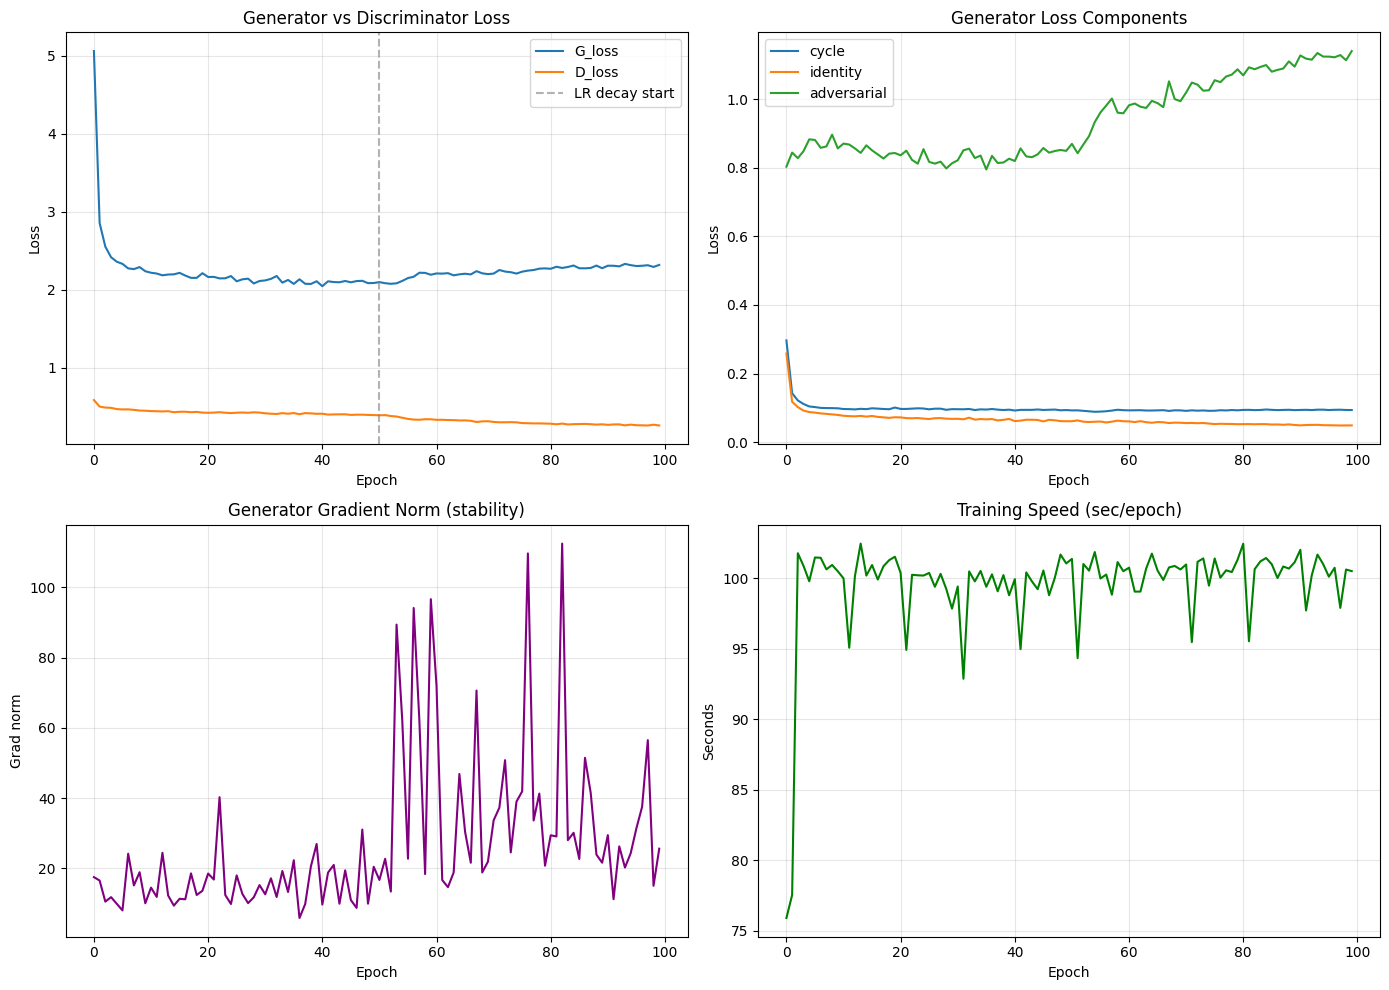

Saved plots to /content/drive/MyDrive/cyclegan_task3/loss_curves_run1.png


In [17]:
# ============================================================================
# LOSS CURVES + STABILITY PLOTS — from run 1 metrics_per_epoch.csv
# ============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Generator vs Discriminator loss
ax = axes[0,0]
ax.plot(df["epoch"], df["G_loss"], label="G_loss")
ax.plot(df["epoch"], df["D_loss"], label="D_loss")
ax.axvline(50, ls="--", c="gray", alpha=0.6, label="LR decay start")
ax.set_title("Generator vs Discriminator Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3)

# (2) Loss components
ax = axes[0,1]
ax.plot(df["epoch"], df["cycle_loss"],    label="cycle")
ax.plot(df["epoch"], df["identity_loss"], label="identity")
ax.plot(df["epoch"], df["adv_loss"],      label="adversarial")
ax.set_title("Generator Loss Components")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3)

# (3) Gradient norm (stability)
ax = axes[1,0]
ax.plot(df["epoch"], df["grad_norm_G"], color="purple")
ax.set_title("Generator Gradient Norm (stability)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Grad norm"); ax.grid(alpha=0.3)

# (4) Seconds per epoch (efficiency)
ax = axes[1,1]
ax.plot(df["epoch"], df["sec_per_epoch"], color="green")
ax.set_title("Training Speed (sec/epoch)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Seconds"); ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(ROOT, "loss_curves_run1.png")
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved plots to {out_path}")


In [25]:
import os, glob, pandas as pd
hits = glob.glob(os.path.join(ROOT, "**/submission*.csv"), recursive=True)
hits += glob.glob(os.path.join(ROOT, "**/logs_run2/*"), recursive=True)
for h in hits: print(h)


/content/drive/MyDrive/cyclegan_task3/submission.csv
/content/drive/MyDrive/cyclegan_task3/BACKUP_run1_unet/submission_run1.csv
/content/drive/MyDrive/cyclegan_task3/logs_run2/metrics_per_epoch_run2.csv
/content/drive/MyDrive/cyclegan_task3/logs_run2/train_run2.log


Run 1: 100 epochs | Run 3: 80 epochs
Run 3 columns: ['epoch', 'G_loss', 'D_loss', 'cycle_loss', 'identity_loss', 'adv_loss', 'grad_norm_G', 'nan_count', 'sec_per_epoch']


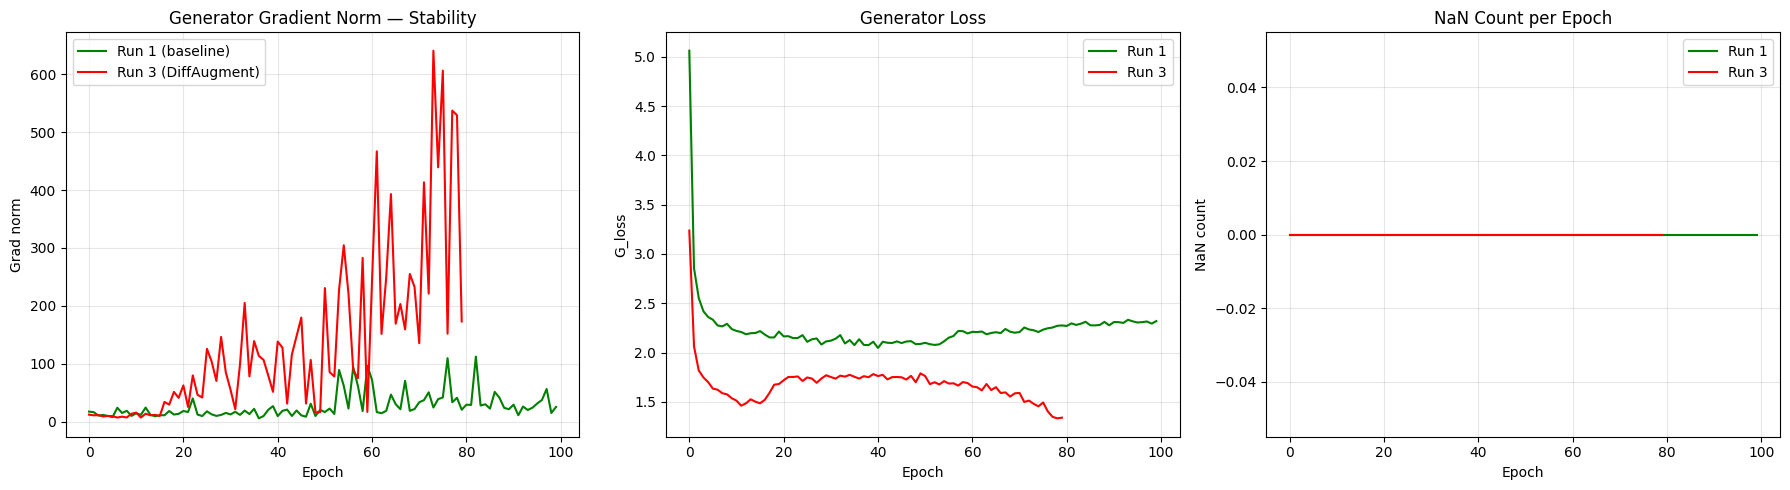

Saved to /content/drive/MyDrive/cyclegan_task3/run1_vs_run3_stability.png

=== STABILITY SUMMARY ===
Run 1 grad_norm: mean 27.0, max 112.5, total NaNs 0
Run 3 grad_norm: mean 137.0, max 640.5, total NaNs 0


In [22]:
# ============================================================================
# RUN 1 vs RUN 3 STABILITY COMPARISON (corrected filename for run 3)
# ============================================================================
import os, pandas as pd, matplotlib.pyplot as plt

LOGS_R1 = os.path.join(ROOT, "logs",      "metrics_per_epoch.csv")  # run 1
LOGS_R3 = os.path.join(ROOT, "logs_run3", "metrics_run3.csv")       # run 3 (correct name)

df1 = pd.read_csv(LOGS_R1)
df3 = pd.read_csv(LOGS_R3)
print(f"Run 1: {len(df1)} epochs | Run 3: {len(df3)} epochs")
print("Run 3 columns:", list(df3.columns))   # confirm columns match
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(df1["epoch"], df1["grad_norm_G"], label="Run 1 (baseline)", color="green")
ax.plot(df3["epoch"], df3["grad_norm_G"], label="Run 3 (DiffAugment)", color="red")
ax.set_title("Generator Gradient Norm — Stability")
ax.set_xlabel("Epoch"); ax.set_ylabel("Grad norm"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df1["epoch"], df1["G_loss"], label="Run 1", color="green")
ax.plot(df3["epoch"], df3["G_loss"], label="Run 3", color="red")
ax.set_title("Generator Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("G_loss"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(df1["epoch"], df1["nan_count"], label="Run 1", color="green")
ax.plot(df3["epoch"], df3["nan_count"], label="Run 3", color="red")
ax.set_title("NaN Count per Epoch")
ax.set_xlabel("Epoch"); ax.set_ylabel("NaN count"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(ROOT, "run1_vs_run3_stability.png")
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")

print("\n=== STABILITY SUMMARY ===")
print(f"Run 1 grad_norm: mean {df1['grad_norm_G'].mean():.1f}, "
      f"max {df1['grad_norm_G'].max():.1f}, total NaNs {df1['nan_count'].sum()}")
print(f"Run 3 grad_norm: mean {df3['grad_norm_G'].mean():.1f}, "
      f"max {df3['grad_norm_G'].max():.1f}, total NaNs {df3['nan_count'].sum()}")


In [24]:
# ============================================================================
# ASSEMBLE full_metrics_report.csv — CORRECTED with verified FID protocol
# ============================================================================
import os, pandas as pd

GPU_NAME = "A100"   # TODO: confirm run 1's training GPU

metrics = {
    # provenance
    "model":                 "run1_epoch060_UNet",
    "checkpoint":            "ckpt_epoch060.pth (backup == main, verified identical)",
    "kaggle_rank":           20,

    # FID — averaged protocol (matches your submission exactly)
    "FID_averaged":          101.44,   # (A2B + B2A)/2  <- your rank-20 score
    "FID_A2B_monet2photo":   103.92,
    "FID_B2A_photo2monet":   98.95,
    "MiFID_A2B":             0.4241,
    "MiFID_B2A":             0.4104,
    "MiFID_reported":        0.4172,   # from submission.csv

    # KID
    "KID_A2B":               0.0191,
    "KID_B2A":               0.0082,
    "KID_avg":               0.0136,

    # cycle / content
    "cycle_L1_avg":          0.0482,
    "content_cosine_avg":    0.7756,

    # perceptual
    "LPIPS_M2P":             0.1806,
    "LPIPS_P2M":             0.2498,
    "LPIPS_avg":             0.2152,

    # precision/recall/density/coverage
    "precision_A2B":         0.6833, "recall_A2B":   0.4433,
    "density_A2B":           0.8627, "coverage_A2B": 0.7900,
    "precision_B2A":         0.5000, "recall_B2A":   0.7300,
    "density_B2A":           0.3847, "coverage_B2A": 0.6933,

    # efficiency
    "params_per_generator_M": 54.40,
    "train_time_hours":       2.77,
    "avg_sec_per_epoch":      99.6,
    "throughput_img_per_sec": 10.04,
    "peak_gpu_mem_MB_infer":  1882,   # inference only; training peak higher (not logged)
    "gpu":                    GPU_NAME,

    # stability (from logs)
    "grad_norm_mean_run1":    27.0, "grad_norm_max_run1": 112.5, "nan_count_run1": 0,

    # experiment comparison (ALL averaged FID, same protocol)
    "run1_FID_avg":           101.44,   # baseline, best, rank 20
    "run2_FID_avg":           101.51,   # lambda tuning, ~tied
    "run3_FID_avg":           112.97,   # DiffAugment, epoch79, worse
    "grad_norm_mean_run3":    137.0, "grad_norm_max_run3": 640.5, "nan_count_run3": 0,
    "run3_epochs_trained":    80,
}

df_metrics = pd.DataFrame([metrics])
out_csv = os.path.join(ROOT, "full_metrics_report.csv")
df_metrics.to_csv(out_csv, index=False)
print(f"Saved {out_csv}\n")
for k,v in metrics.items():
    print(f"  {k:28s}: {v}")


Saved /content/drive/MyDrive/cyclegan_task3/full_metrics_report.csv

  model                       : run1_epoch060_UNet
  checkpoint                  : ckpt_epoch060.pth (backup == main, verified identical)
  kaggle_rank                 : 20
  FID_averaged                : 101.44
  FID_A2B_monet2photo         : 103.92
  FID_B2A_photo2monet         : 98.95
  MiFID_A2B                   : 0.4241
  MiFID_B2A                   : 0.4104
  MiFID_reported              : 0.4172
  KID_A2B                     : 0.0191
  KID_B2A                     : 0.0082
  KID_avg                     : 0.0136
  cycle_L1_avg                : 0.0482
  content_cosine_avg          : 0.7756
  LPIPS_M2P                   : 0.1806
  LPIPS_P2M                   : 0.2498
  LPIPS_avg                   : 0.2152
  precision_A2B               : 0.6833
  recall_A2B                  : 0.4433
  density_A2B                 : 0.8627
  coverage_A2B                : 0.79
  precision_B2A               : 0.5
  recall_B2A           